# Libs

In [2]:
import sys
sys.path.append('../..')

from importlib import reload
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import scipy.optimize as sci
import pickle
# %matplotlib notebook

# %config InlineBackend.figure_format='retina'

In [4]:
import sys
sys.path.append('C:\\Users\\Professional\\Documents\\GitHub\\labs_center\\')
# import labs_center
from sparam_fit import fit_amp_phase, fit_circle, fit_hybrid, fit_magnitude_only

In [6]:
from sparam_fit import fit_amp_phase, fit_circle, fit_hybrid, fit_magnitude_only
from sparam_fit.models import ResonatorParams, model_s
from sparam_fit.synthetic import make_trace
from sparam_fit.plots import plot_fit_report, plot_delay_before_after
from sparam_fit.guess import guess_delay_linear, refine_delay_circle, remove_delay

# Single resonator

$$S_{21} = a e^{i\alpha} e^{-2\pi i f \tau}\left[ 1 - \frac{Q_l/|Q_c|e^{i \varphi}}{1 + 2iQ_l(f/f_r - 1)}\right]$$           

In [10]:
def S21_funcUst_Full(omega, omega_r, phi = 2 * np.pi, a = 1, alpha = 1, t = 1, Q_l = 1000, Q_c = 2000): 
    
    S_func = np.zeros_like(omega)
    S_func = a * np.exp(1j*alpha) * np.exp(-2*np.pi*1j*omega*t) * (1 - (np.exp(1j * phi) * Q_l/np.abs(Q_c))/(1 + 2 * 1j * Q_l * ((omega)/(omega_r) - 1) ))
   
    return S_func


# DICT OF ALL SIM

In [13]:
if 'Meas_dict' not in globals():
    # Meas_dict =  { 'meas_num':[],
    #             'type_of_meas':[],
    #             'data_params': []
    # }
    Meas_dict =  { 
    }
    print ('Meas_dict added')
else:
    print ('uzhe\n',Meas_dict)
typo =  { 'title': None,
            'subject': None,
            'type_of_meas': [],
            'data_params': {
                    
            } 
        }

Meas_dict added


In [19]:
# if not(f'{meas_num}' in Meas_dict):
#     Meas_dict[f'{meas_num}'] = typo
#     Meas_dict[f'{meas_num}']['title'] = title
#     Meas_dict[f'{meas_num}']['subject'] = subject
#     print(f'meas_num = {meas_num} added')
# else:
#     print('Error')
# # data1.shape, data1, y1.shape, y1
# Meas_dict

# Full Data

## Download data


### CSV

In [24]:
link_re = r'C:\Users\Professional\Documents\Romas_lib\QCreator2\designs\FlipChip\080926_RESONATORS_20Q-1\S21db_695_re.csv'
link_im = r'C:\Users\Professional\Documents\Romas_lib\QCreator2\designs\FlipChip\080926_RESONATORS_20Q-1\S21db_695_im.csv'
df_re = pd.read_csv(link_re, delimiter = ',')
df_im = pd.read_csv(link_im, delimiter = ',')

S21_data = df_re['re(S(2,1)) []'] + 1j * df_im['im(S(2,1)) []']
omega_data = df_re['Freq [GHz]'] * 1e9


df_re.columns, df_im.columns
# df.describe()

# # sns.scatterplot(df, x = df['Freq [GHz]'], y = df['dB(S(2,1)) []'])

(Index(['Freq [GHz]', 're(S(2,1)) []'], dtype='object'),
 Index(['Freq [GHz]', 'im(S(2,1)) []'], dtype='object'))

### Mesura

In [27]:
# C:\\Users\\Professional\\Documents\\Romas_lib\\QCreator2\\designs\\Finger_quantim_capasitor\\Analisis\\Meash_purc_res\\2025-05-28\\
link1 = "C:\\Users\\Professional\\Documents\\Romas_lib\\FlipChip_Rustam\\Second_mesura_Oxford\\OneTone\\"
link2_data = "\\S-parameter\\data\\data.npy"
link2_y = "\\S-parameter\\parameters\\1\\data.npy"
link2_x = "\\S-parameter\\parameters\\0\\data.npy"

meas_num = "101576"
title = 'resonator_frequency-Flip_Chip_second'
subject = '6 Res'
 
data1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_data)
                                                                                                      

try:
    y1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_y)       #power
    x1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_x)       #freq
    subject+=' 3D data'
    print("3D data")
except FileNotFoundError:
    y1 = [1]
    x1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_x)       #freq
    subject+=' 2D data'
    print("2D data")

Data = []
for i in range(len(y1)):
    a = [0] * len(x1)
    Data.append(a)
for i in range(len(x1)):
    for j in range(len(y1)):
        if len(y1) == 1:
            Data[0][i] = data1[i]
        else:
            Data[j][i] = data1[j][i]

# Нормализую назване
omega_data = x1
S21_data = Data[0]

2D data


In [29]:
if not(f'{meas_num}' in Meas_dict):
    Meas_dict[f'{meas_num}'] = typo
    Meas_dict[f'{meas_num}']['title'] = title
    Meas_dict[f'{meas_num}']['subject'] = subject
    print(f'meas_num = {meas_num} added')
else:
    print('Error')
# data1.shape, data1, y1.shape, y1
Meas_dict

meas_num = 101576 added


{'101576': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '6 Res 2D data',
  'type_of_meas': [],
  'data_params': {}}}

In [31]:
# FIT

## ABS

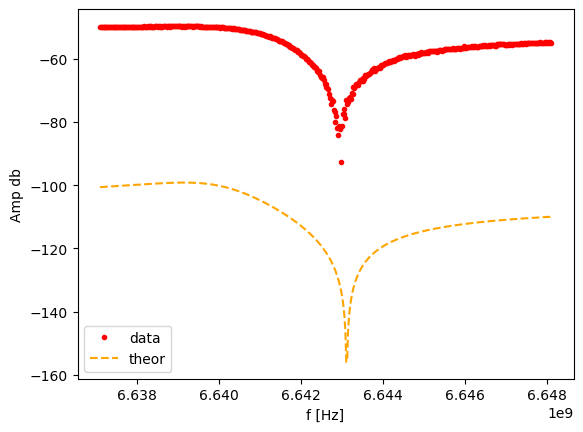

In [34]:
''' S-parametr is complex value !!!'''

'''ABS'''

a, b = 0, len(omega_data)
omega_data_s = omega_data[a: b] 
S21_data_s = S21_data[a: b] 

Fit_abs = fit_magnitude_only(omega_data_s, np.abs(S21_data_s)**2, geometry="notch")
S21_Fit_abs = S21_funcUst_Full(omega_data_s, omega_r = Fit_abs.params.fr, 
                                phi = Fit_abs.params.phi, alpha = Fit_abs.params.alpha, 
                                a = Fit_abs.params.a, t = Fit_abs.params.tau, 
                                Q_l = Fit_abs.params.Ql, Q_c = Fit_abs.params.absQc)

plt.plot(omega_data_s, 10*np.log10(np.abs(S21_data_s)**2), '.',label = "data", color = 'red')
plt.plot(omega_data_s, 10*np.log10(np.abs(S21_Fit_abs)**2), '--', label = "theor", color = 'orange')
plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()
plt.show()

## AMP + PHASE

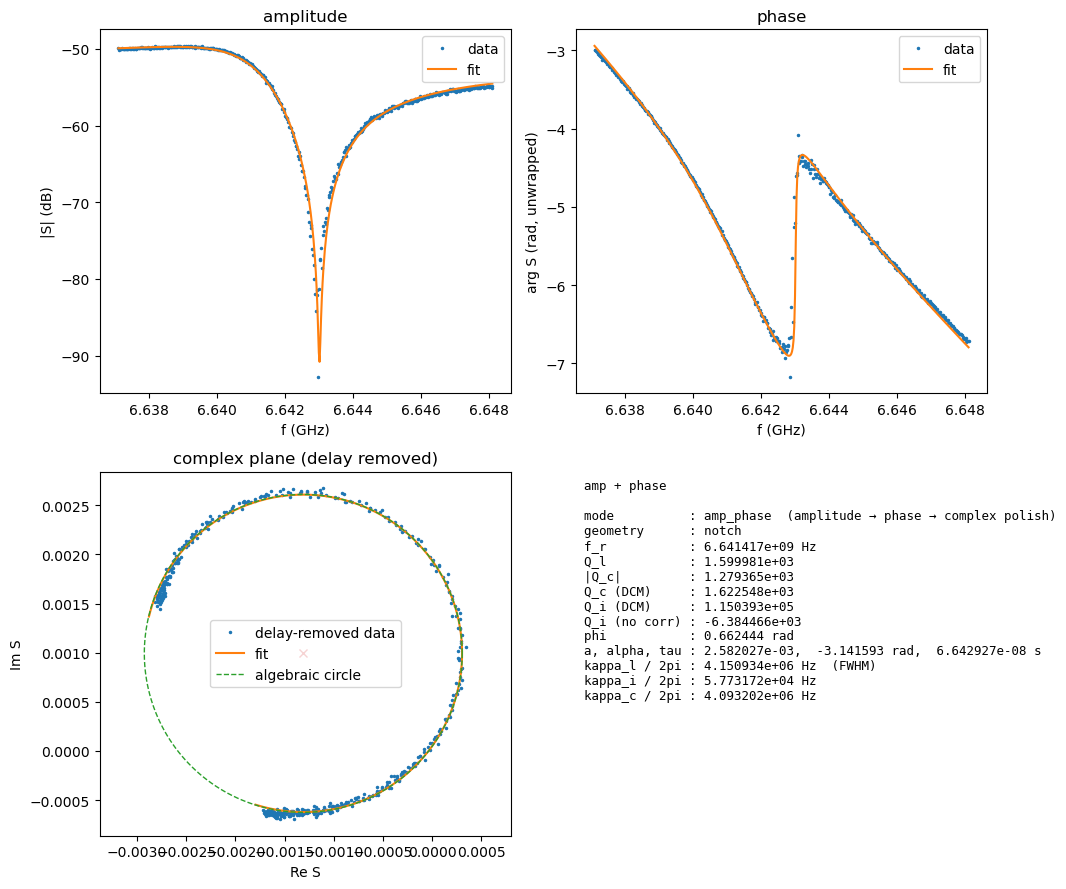

In [37]:
''' S-parametr is complex value !!!'''

'''AMP + PHASE'''

a, b = 0, len(omega_data)
omega_data_s = omega_data[a: b] 
S21_data_s = S21_data[a: b] 

Fit_amp_phase = fit_amp_phase(omega_data_s, S21_data_s, geometry="notch")
S21_Fit_amp_phase = S21_funcUst_Full(omega_data_s, omega_r = Fit_amp_phase.params.fr, 
                                phi = Fit_amp_phase.params.phi, alpha = Fit_amp_phase.params.alpha, 
                                a = Fit_amp_phase.params.a, t = Fit_amp_phase.params.tau, 
                                Q_l = Fit_amp_phase.params.Ql, Q_c = Fit_amp_phase.params.absQc)

plot_fit_report(omega_data_s, S21_data_s, Fit_amp_phase, title='amp + phase')
plt.show()

# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_data_s)**2), '.',label = "data", color = 'orange')
# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_Fit_amp_phase)**2), '--', label = "theor", color = 'blue')
# plt.legend()
# plt.xlabel('f [Hz]') 
# plt.ylabel('Amp db')
# plt.show()


## CIRCLE

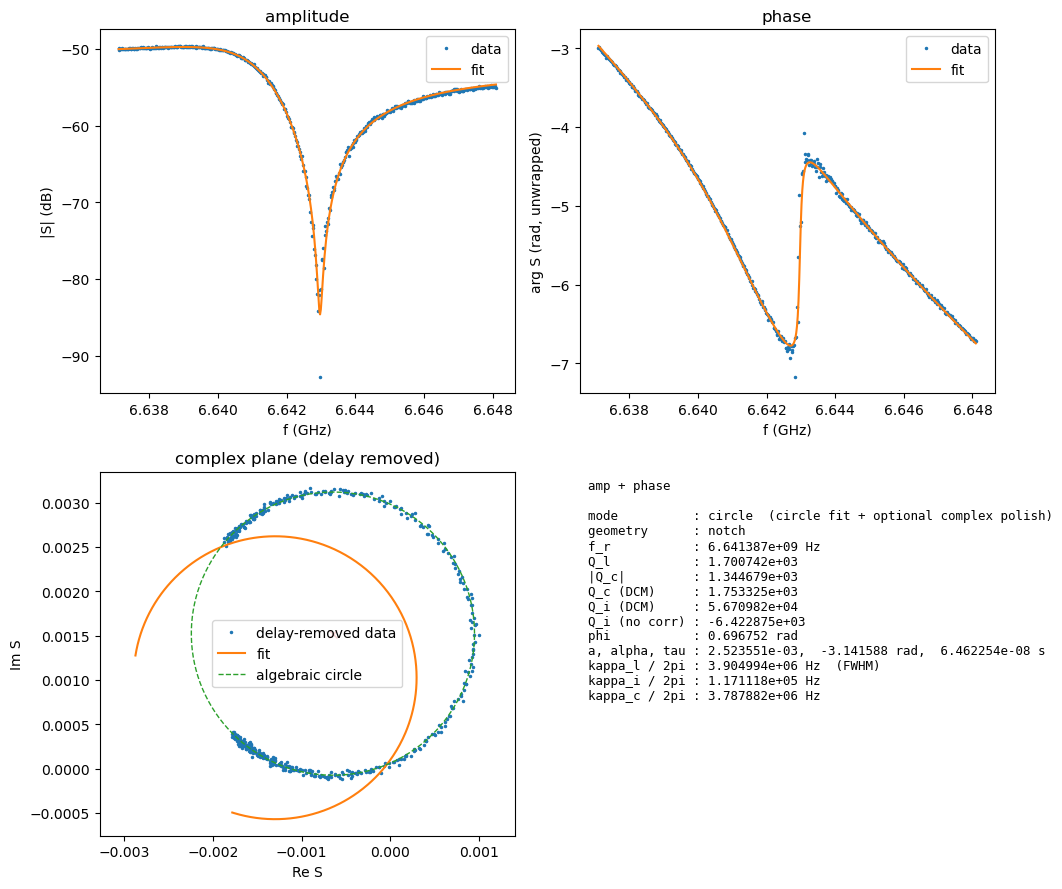

In [40]:
''' S-parametr is complex value !!!'''

'''circle'''

a, b = 0, len(omega_data)
omega_data_s = omega_data[a: b] 
S21_data_s = S21_data[a: b] 

Fit_circle = fit_circle(omega_data_s, S21_data_s, geometry="notch")
S21_Fit_circle = S21_funcUst_Full(omega_data_s, omega_r = Fit_circle.params.fr, 
                                phi = Fit_circle.params.phi, alpha = Fit_circle.params.alpha, 
                                a = Fit_circle.params.a, t = Fit_circle.params.tau, 
                                Q_l = Fit_circle.params.Ql, Q_c = Fit_circle.params.absQc)

plot_fit_report(omega_data_s, S21_data_s, Fit_circle, title='amp + phase')
plt.show()

# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_data_s)**2), '.',label = "data", color = 'orange')
# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_Fit_amp_phase)**2), '--', label = "theor", color = 'blue')
# plt.legend()
# plt.xlabel('f [Hz]') 
# plt.ylabel('Amp db')
# plt.show()


## HYBRID

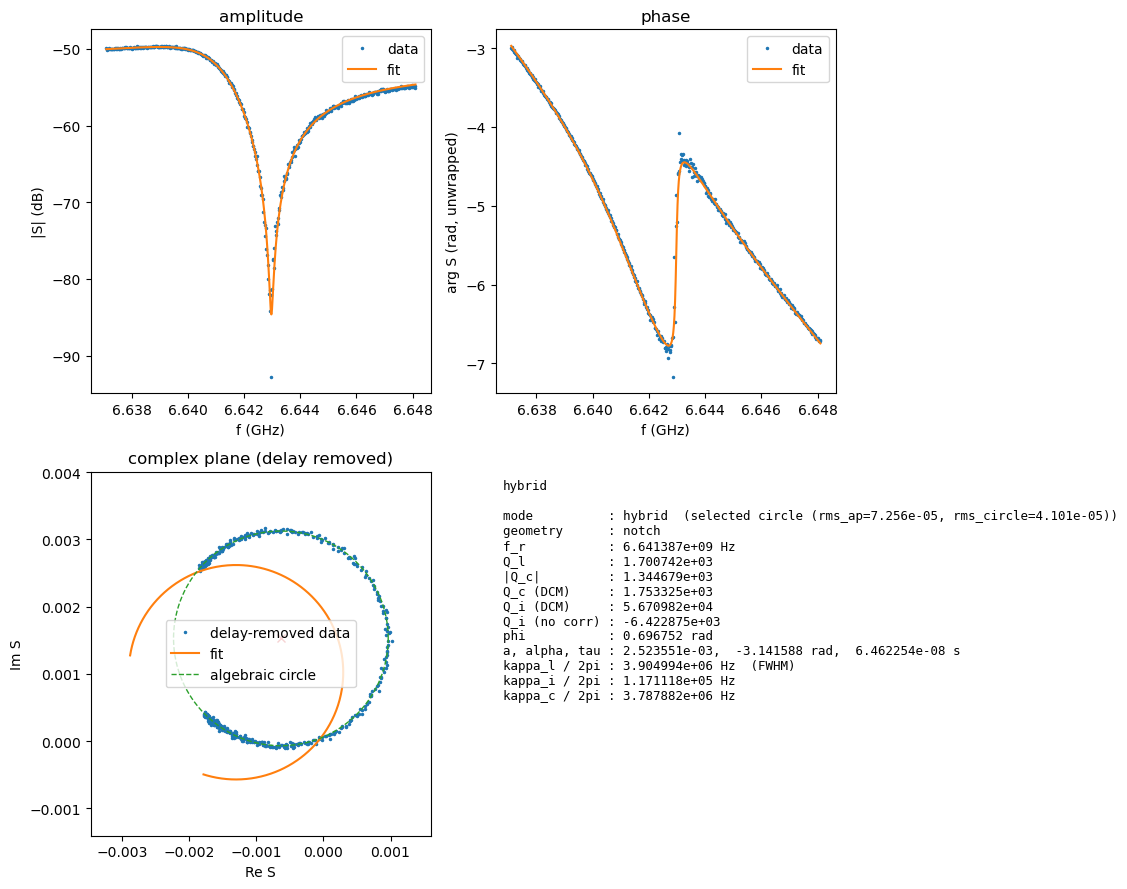

In [42]:
''' S-parametr is complex value !!!'''

'''hybrid'''

a, b = 0, len(omega_data)
omega_data_s = omega_data[a: b] 
S21_data_s = S21_data[a: b] 

Fit_hybrid, fir_ap, fit_c = fit_hybrid(omega_data_s, S21_data_s, geometry="notch")
S21_Fit_hybrid = S21_funcUst_Full(omega_data_s, omega_r = Fit_hybrid.params.fr, 
                                phi = Fit_hybrid.params.phi, alpha = Fit_hybrid.params.alpha, 
                                a = Fit_hybrid.params.a, t = Fit_hybrid.params.tau, 
                                Q_l = Fit_hybrid.params.Ql, Q_c = Fit_hybrid.params.absQc)

plot_fit_report(omega_data_s, S21_data_s, Fit_hybrid, title='hybrid')
plt.show()

# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_data_s)**2), '.',label = "data", color = 'orange')
# plt.plot(omega_data_s, 10*np.log10(np.abs(S21_Fit_amp_phase)**2), '--', label = "theor", color = 'blue')
# plt.legend()
# plt.xlabel('f [Hz]') 
# plt.ylabel('Amp db')
# plt.show()


# Amplitude Data ONLY

In [46]:
# link = r'C:\Users\Professional\Documents\Romas_lib\FlipChip_Rustam\Files_simul\S21_X-mon_3D_res_tml_6Q_10mkm_500mhz.csv'
link = r'C:\Users\Professional\Documents\Romas_lib\QCreator2\designs\FlipChip\080926_RESONATORS_20Q-1\S21db_695.csv'
df = pd.read_csv(link, delimiter = ',')
S_data = df.values
# # S_data2 = df2.values
df.head()

df.columns
# # df.describe()
# df
# # sns.scatterplot(df, x = df['Freq [GHz]'], y = df['dB(S(2,1)) []'])

Index(['Freq [GHz]', 'dB(S(2,1)) []'], dtype='object')

In [48]:
# om = df['Freq [GHz]'][a_:b]
# om[a_+1]
df['dB(S(2,1)) []']
df['dB(S(2,1)) []'].shape
# omega_data.shape

(20001,)

In [50]:
omega_data = (df['Freq [GHz]']*1e9).to_numpy()
S21_data = df['dB(S(2,1)) []'].to_numpy() 

## S-parametr is only ABS DB !!!

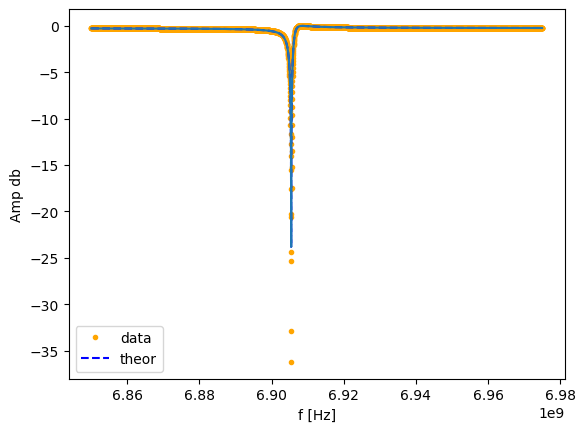

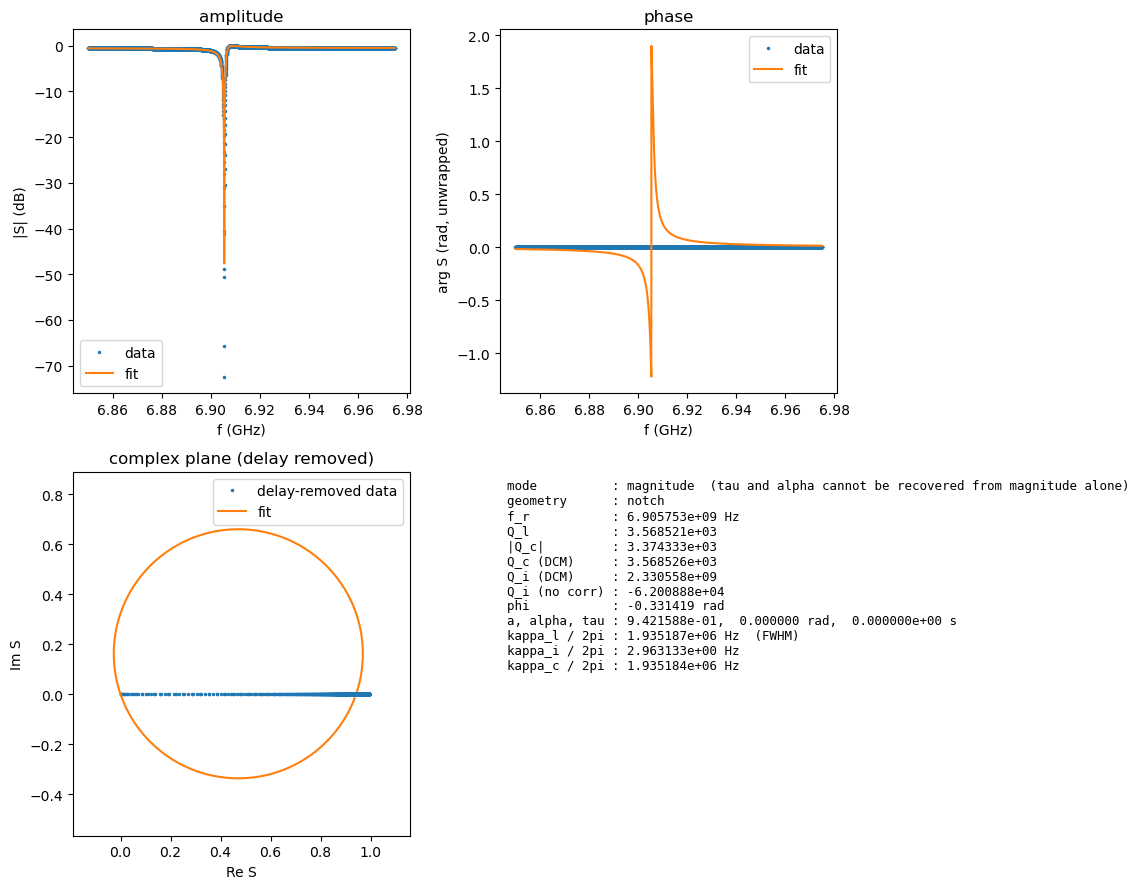

In [54]:
''' S-parametr is only ABS DB !!!'''

a, b = 8000,13000#0, len(omega_data)
omega_data_s = omega_data[a: b] 
S21_data_s = S21_data[a: b] 

First_try_fit = fit_magnitude_only(omega_data_s, 10**(S21_data_s/10), geometry="notch")
First_try = S21_funcUst_Full(omega_data_s, omega_r = First_try_fit.params.fr, 
                                phi = First_try_fit.params.phi, alpha = First_try_fit.params.alpha, 
                                a = First_try_fit.params.a, t = First_try_fit.params.tau, 
                                Q_l = First_try_fit.params.Ql, Q_c = First_try_fit.params.absQc)


plt.plot(omega_data_s, S21_data_s, '.',label = "data", color = 'orange')
plt.plot(omega_data_s, 10*np.log10(np.abs(First_try)), '--', label = "theor", color = 'blue')
plt.plot(omega_data_s, 10*np.log10(np.abs(model_s(omega_data_s, First_try_fit.params))))
plt.legend()
plt.xlabel('f [Hz]') 
plt.ylabel('Amp db')
plt.show()
plot_fit_report(omega_data_s, 10**(S21_data_s/10), First_try_fit)
plt.show()





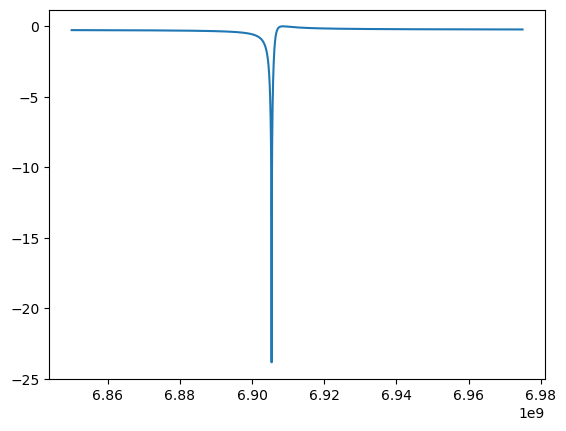

In [56]:
plt.plot(omega_data_s, 10*np.log10(np.abs(model_s(omega_data_s, First_try_fit.params))))

# ANDREY SIM RESONATORS

In [59]:
import copy

In [369]:
{'101576': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '6 Res 2D data',
  'type_of_meas': [],
  'data_params': {}}}

{'101576': {'title': 'resonator_frequency-Flip_Chip_second',
  'subject': '6 Res 2D data',
  'type_of_meas': [],
  'data_params': {}}}

In [371]:
typo =  { 'title': None,
            'subject': None,
            'type_of_meas': [],
            'data_params': {
                    
            } 
        }
# if not(f'{meas_num}' in Meas_dict):
#     Meas_dict[f'{meas_num}'] = typo
#     Meas_dict[f'{meas_num}']['title'] = title
#     Meas_dict[f'{meas_num}']['subject'] = subject
#     print(f'meas_num = {meas_num} added')
# else:
#     print('Error')
# data1.shape, data1, y1.shape, y1
# Meas_dict


In [373]:
title = '20Q resonators'

for i in range(10):
    it = 695 + 5*i
    print(it)
    if i != 7:
        meas_num = f'S21db_{it}'
        subject = f'Res {it}'
        link_re = fr'C:\Users\Professional\Documents\Romas_lib\QCreator2\designs\FlipChip\080926_RESONATORS_20Q-1\{meas_num}_re.csv'
        link_im = fr'C:\Users\Professional\Documents\Romas_lib\QCreator2\designs\FlipChip\080926_RESONATORS_20Q-1\{meas_num}_im.csv'
        df_re = pd.read_csv(link_re, delimiter = ',')
        df_im = pd.read_csv(link_im, delimiter = ',')
        
        S21_data = (S21_data_re.to_numpy()  + S21_data_im.to_numpy() )[5000:15000]
        omega_data = ((df_re['Freq [GHz]'] * 1e9).to_numpy())[5000:15000]
        Meas_dict[f'{meas_num}'] = copy.deepcopy(typo)
        Meas_dict[f'{meas_num}']['title'] = title
        Meas_dict[f'{meas_num}']['subject'] = subject
        
        Meas_dict[f'{meas_num}']['data_params']['S21_data'] = S21_data
        Meas_dict[f'{meas_num}']['data_params']['omega_data'] = omega_data
        
        Fit_hybrid, a, b = fit_hybrid(omega_data, S21_data, geometry="notch")
        Meas_dict[f'{meas_num}']['data_params']['fit_hybrid'] = Fit_hybrid



695
700
705
710
715
720
725
730
735
740


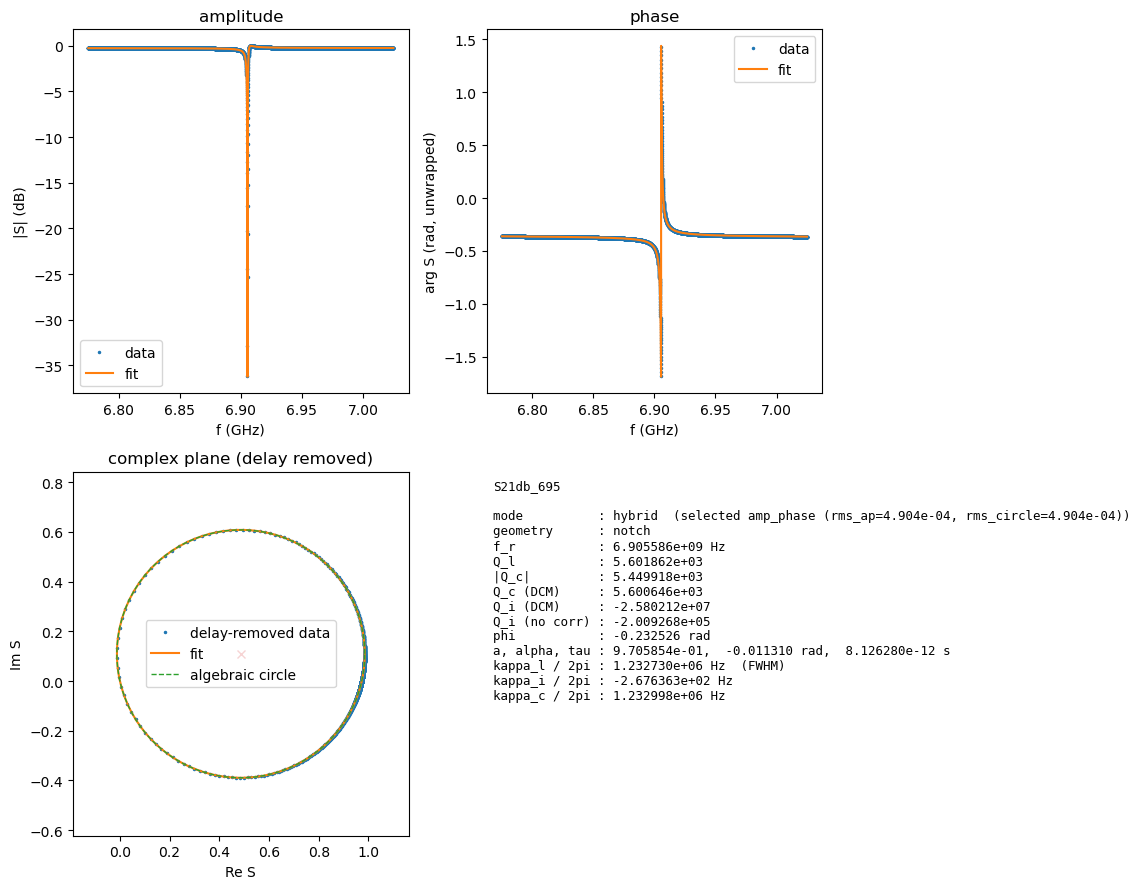

mode          : hybrid  (selected amp_phase (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 6.905586e+09 Hz
Q_l           : 5.601862e+03
|Q_c|         : 5.449918e+03
Q_c (DCM)     : 5.600646e+03
Q_i (DCM)     : -2.580212e+07
Q_i (no corr) : -2.009268e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  -0.011310 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


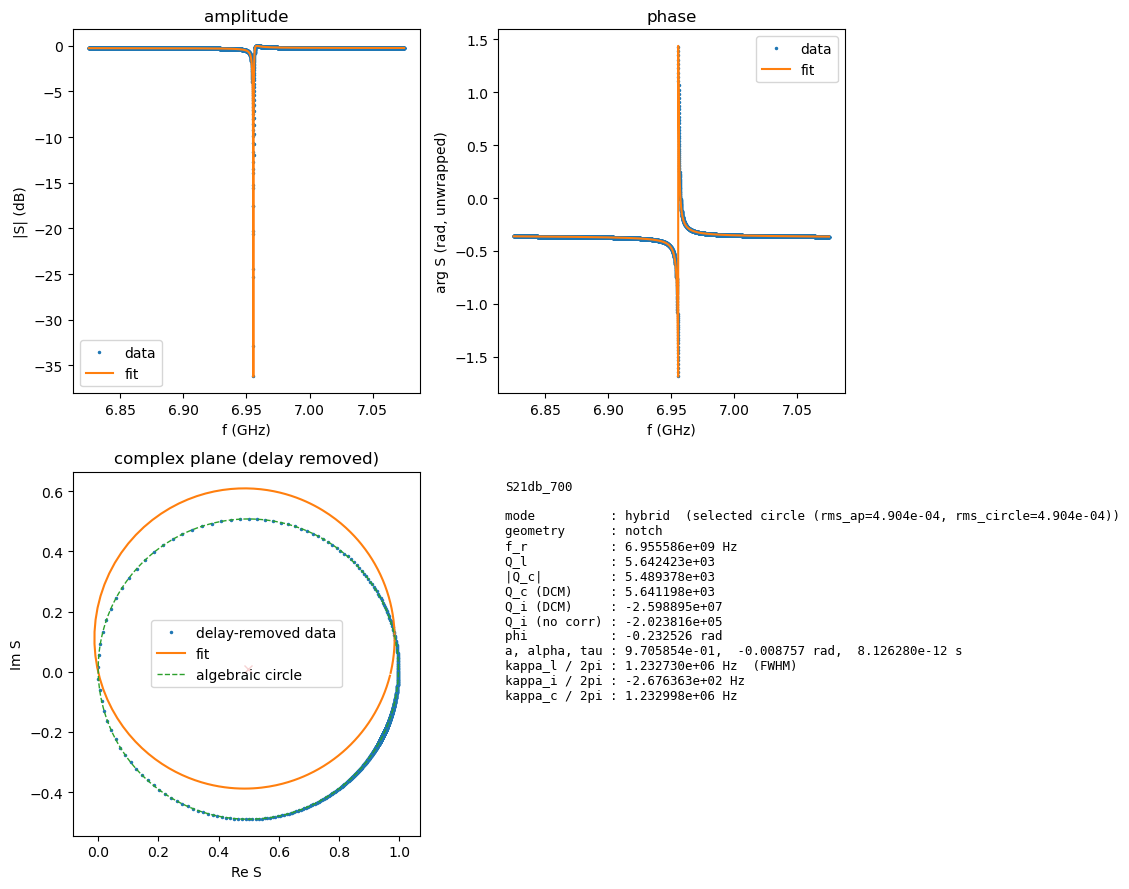

mode          : hybrid  (selected circle (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 6.955586e+09 Hz
Q_l           : 5.642423e+03
|Q_c|         : 5.489378e+03
Q_c (DCM)     : 5.641198e+03
Q_i (DCM)     : -2.598895e+07
Q_i (no corr) : -2.023816e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  -0.008757 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


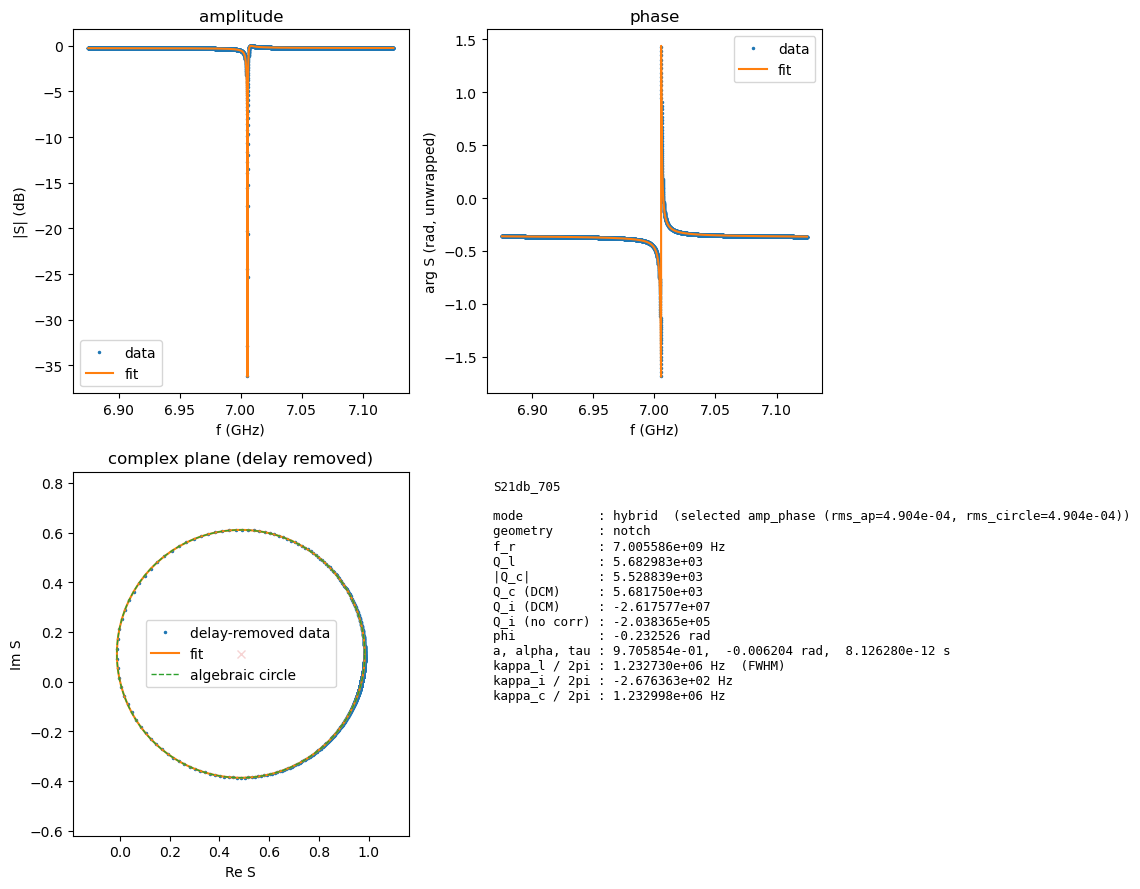

mode          : hybrid  (selected amp_phase (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.005586e+09 Hz
Q_l           : 5.682983e+03
|Q_c|         : 5.528839e+03
Q_c (DCM)     : 5.681750e+03
Q_i (DCM)     : -2.617577e+07
Q_i (no corr) : -2.038365e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  -0.006204 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


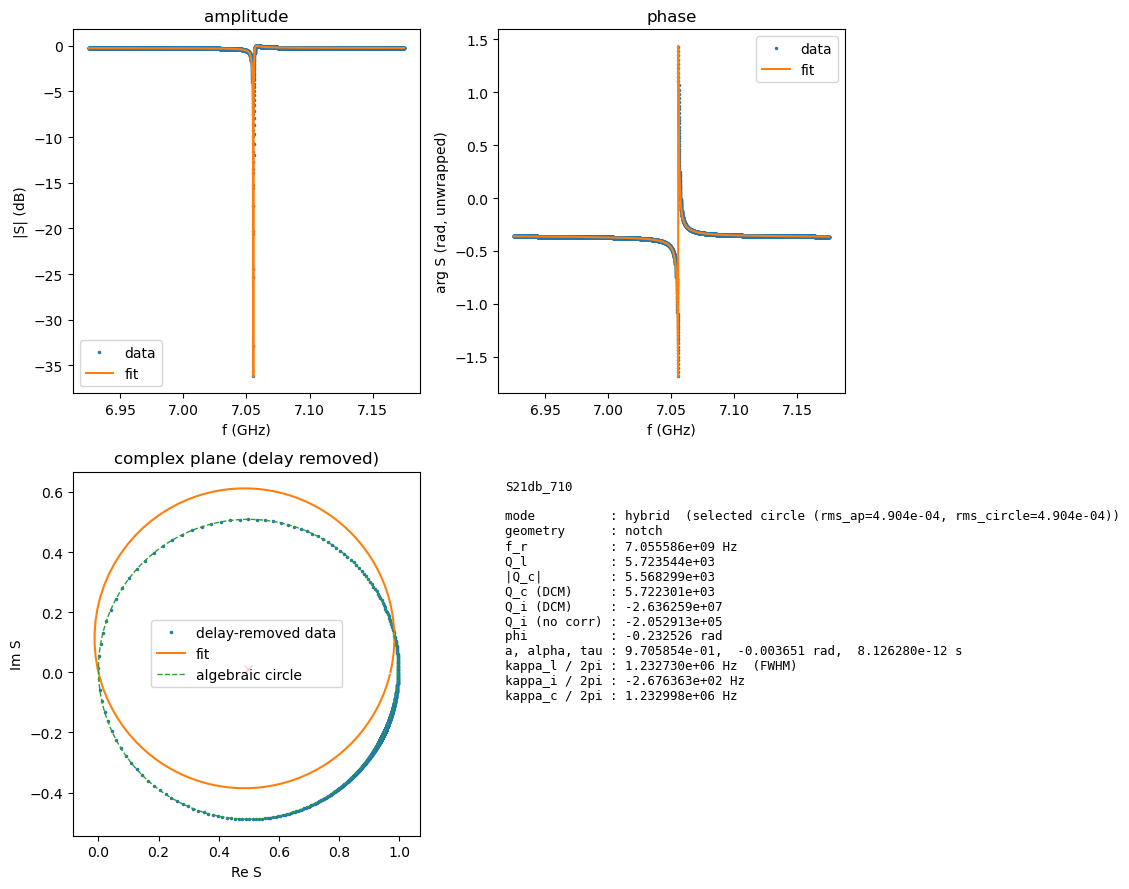

mode          : hybrid  (selected circle (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.055586e+09 Hz
Q_l           : 5.723544e+03
|Q_c|         : 5.568299e+03
Q_c (DCM)     : 5.722301e+03
Q_i (DCM)     : -2.636259e+07
Q_i (no corr) : -2.052913e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  -0.003651 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


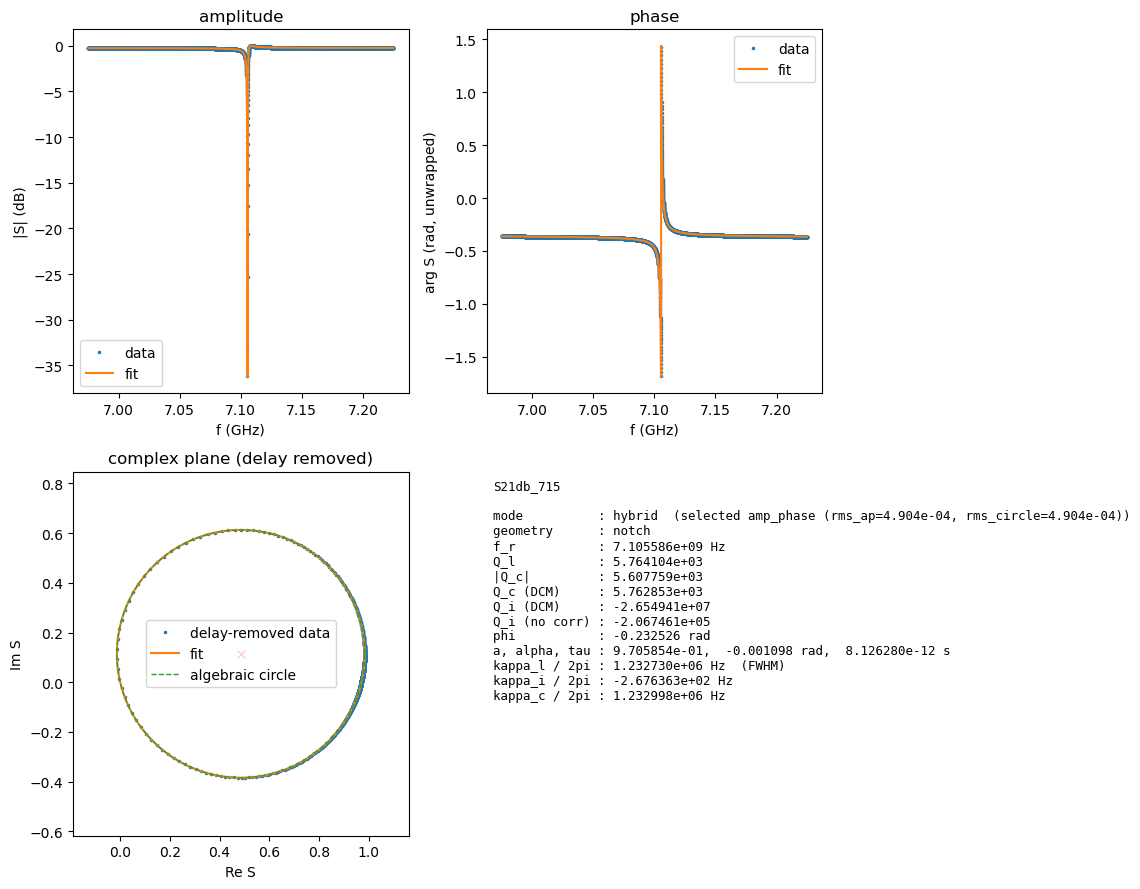

mode          : hybrid  (selected amp_phase (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.105586e+09 Hz
Q_l           : 5.764104e+03
|Q_c|         : 5.607759e+03
Q_c (DCM)     : 5.762853e+03
Q_i (DCM)     : -2.654941e+07
Q_i (no corr) : -2.067461e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  -0.001098 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


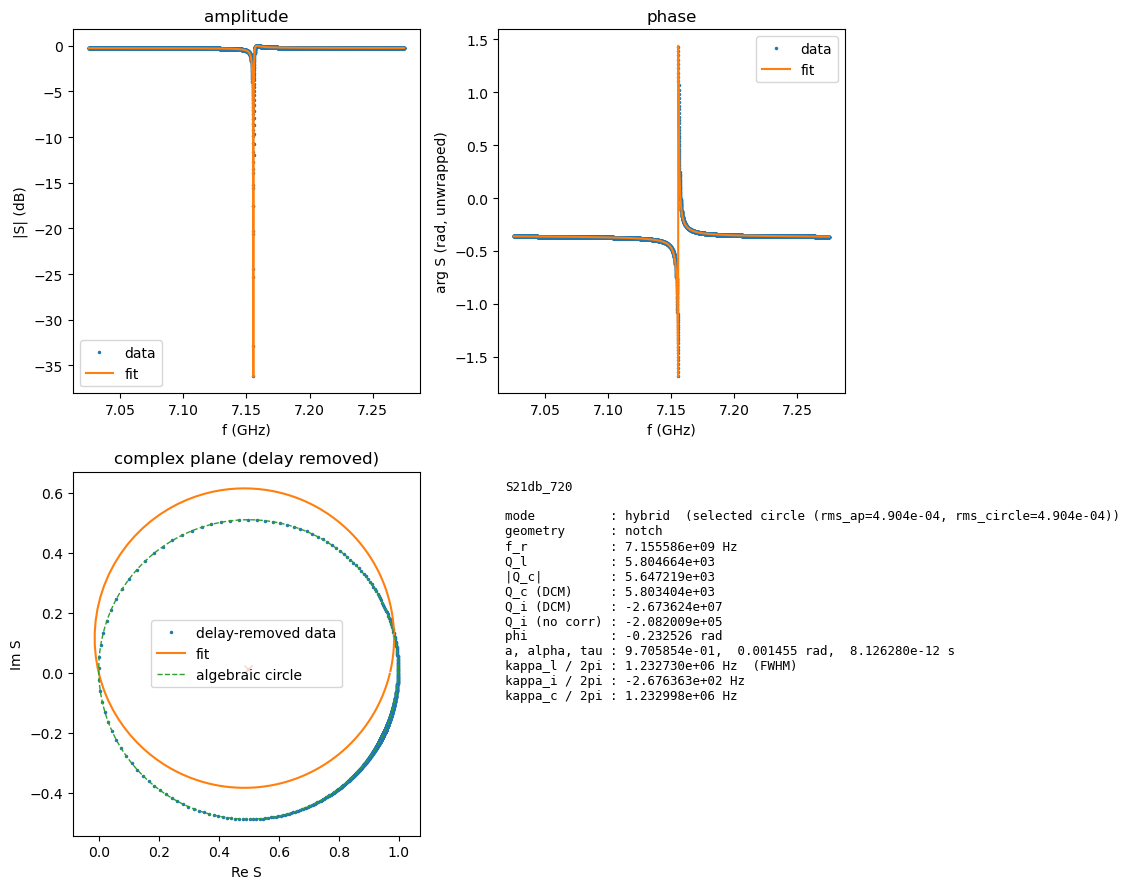

mode          : hybrid  (selected circle (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.155586e+09 Hz
Q_l           : 5.804664e+03
|Q_c|         : 5.647219e+03
Q_c (DCM)     : 5.803404e+03
Q_i (DCM)     : -2.673624e+07
Q_i (no corr) : -2.082009e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  0.001455 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676363e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


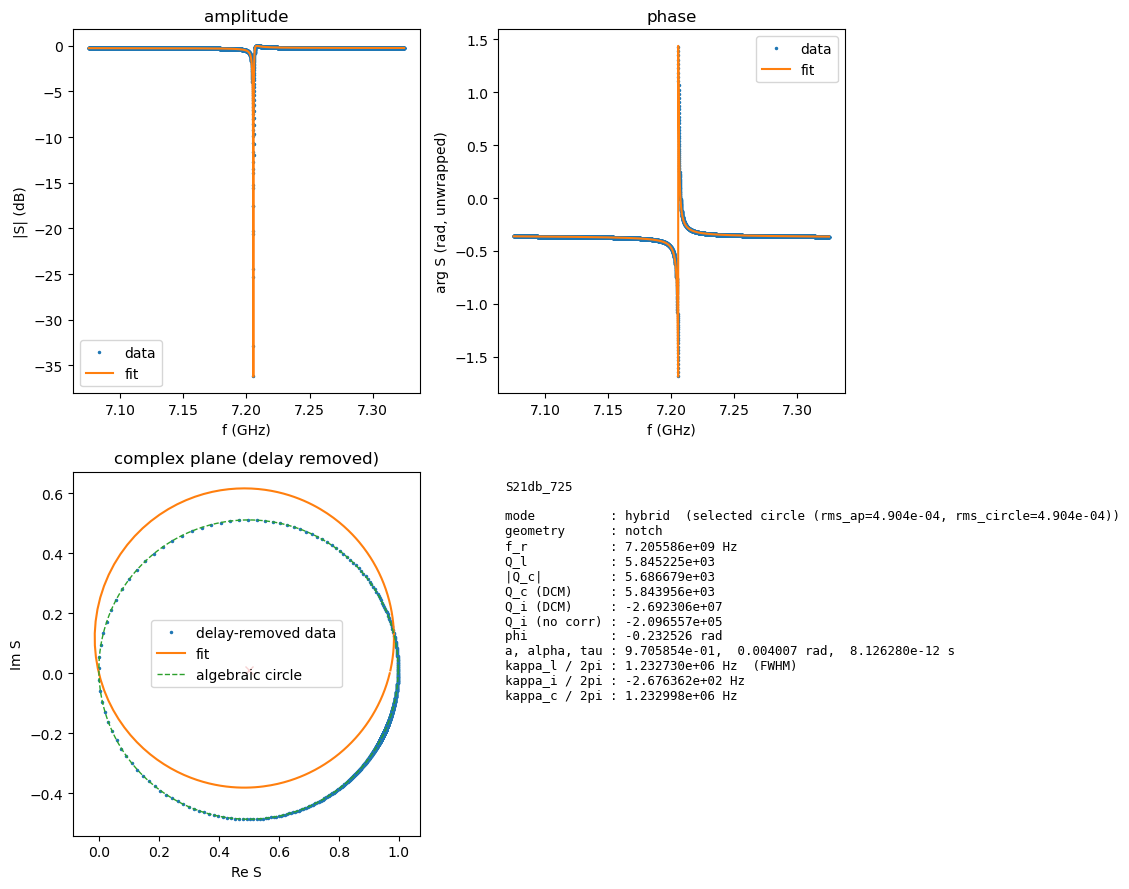

mode          : hybrid  (selected circle (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.205586e+09 Hz
Q_l           : 5.845225e+03
|Q_c|         : 5.686679e+03
Q_c (DCM)     : 5.843956e+03
Q_i (DCM)     : -2.692306e+07
Q_i (no corr) : -2.096557e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  0.004007 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676362e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


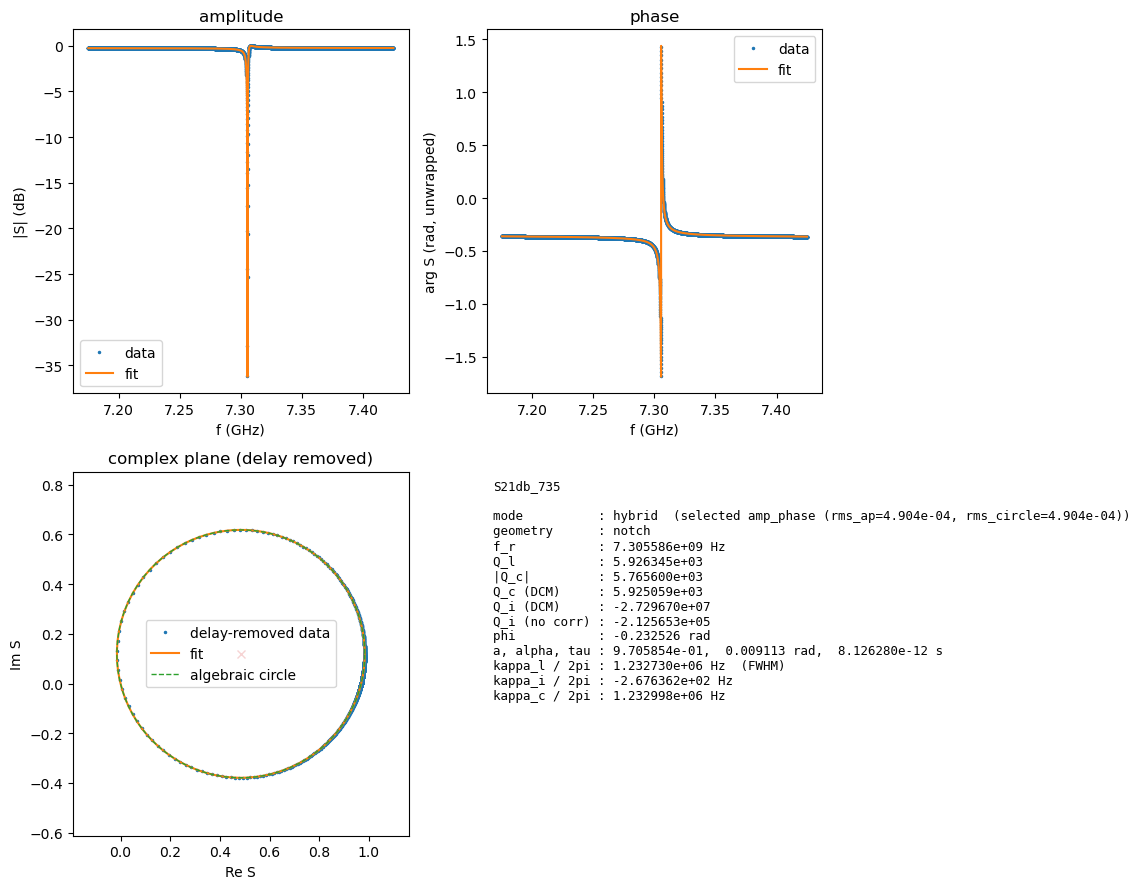

mode          : hybrid  (selected amp_phase (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.305586e+09 Hz
Q_l           : 5.926345e+03
|Q_c|         : 5.765600e+03
Q_c (DCM)     : 5.925059e+03
Q_i (DCM)     : -2.729670e+07
Q_i (no corr) : -2.125653e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  0.009113 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676362e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


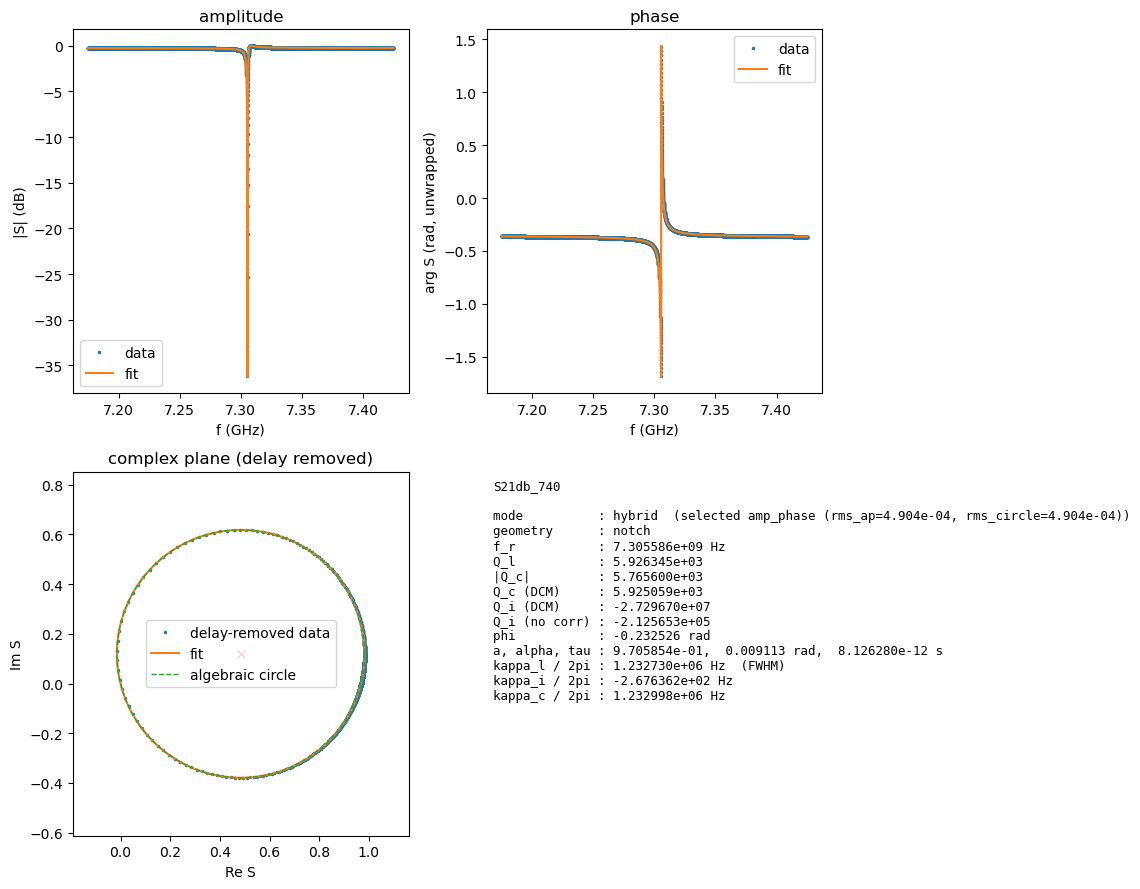

mode          : hybrid  (selected amp_phase (rms_ap=4.904e-04, rms_circle=4.904e-04))
geometry      : notch
f_r           : 7.305586e+09 Hz
Q_l           : 5.926345e+03
|Q_c|         : 5.765600e+03
Q_c (DCM)     : 5.925059e+03
Q_i (DCM)     : -2.729670e+07
Q_i (no corr) : -2.125653e+05
phi           : -0.232526 rad
a, alpha, tau : 9.705854e-01,  0.009113 rad,  8.126280e-12 s
kappa_l / 2pi : 1.232730e+06 Hz  (FWHM)
kappa_i / 2pi : -2.676362e+02 Hz
kappa_c / 2pi : 1.232998e+06 Hz


In [402]:
for i in range(10):
    it = 695 + 5*i
    if i != 7:
        plot_fit_report(Meas_dict[f'S21db_{it}']['data_params']['omega_data'], 
                        Meas_dict[f'S21db_{it}']['data_params']['S21_data'], 
                        Meas_dict[f'S21db_{it}']['data_params']['fit_hybrid'], title = f'S21db_{it}')
        plt.show()
        print(Meas_dict[f'S21db_{it}']['data_params']['fit_hybrid'].summary())

# FLIPCHIP MEAS

In [378]:
link1 = "C:\\Users\\Professional\\Documents\\Romas_lib\\FlipChip_Rustam\\Second_mesura_Oxford\\OneTone\\"
link2_data = "\\S-parameter\\data\\data.npy"
link2_y = "\\S-parameter\\parameters\\1\\data.npy"
link2_x = "\\S-parameter\\parameters\\0\\data.npy"



In [384]:
title = 'FlipChip_meas'

for E in range(7):
    meas_num = f'{101566 + 2*E}'
    print(meas_num)
    title = 'resonator_frequency-Flip_Chip_second'
    subject = f'{E+1} Res'
     
    data1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_data)

    x1 = np.load(link1 + f"{meas_num}-resonator_frequency-Flip_Chip_second.exdir" + link2_x) 

    
    Data = []
    for i in range(len(y1)):
        a = [0] * len(x1)
        Data.append(a)
    for i in range(len(x1)):
        for j in range(len(y1)):
            if len(y1) == 1:
                Data[0][i] = data1[i]
            else:
                Data[j][i] = data1[j][i]
    
    # Нормализую назване
    omega_data = x1
    S21_data = Data[0]

    Meas_dict[f'{meas_num}'] = copy.deepcopy(typo)
    Meas_dict[f'{meas_num}']['title'] = title
    Meas_dict[f'{meas_num}']['subject'] = subject
    
    Meas_dict[f'{meas_num}']['data_params']['S21_data'] = S21_data
    Meas_dict[f'{meas_num}']['data_params']['omega_data'] = omega_data

    Fit_hybrid, a, b = fit_hybrid(omega_data, S21_data, geometry="notch")
    Meas_dict[f'{meas_num}']['data_params']['fit_hybrid'] = Fit_hybrid




101566
101568
101570
101572
101574
101576
101578


101566


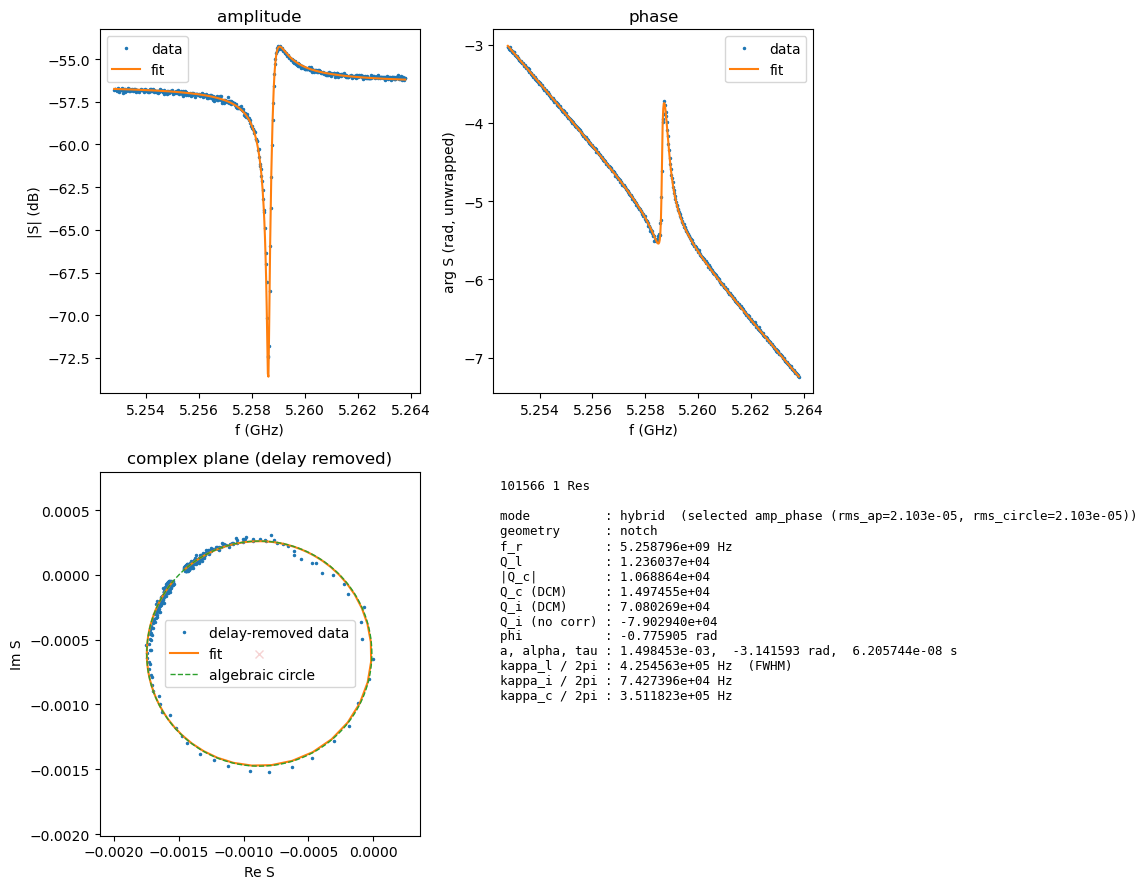

mode          : hybrid  (selected amp_phase (rms_ap=2.103e-05, rms_circle=2.103e-05))
geometry      : notch
f_r           : 5.258796e+09 Hz
Q_l           : 1.236037e+04
|Q_c|         : 1.068864e+04
Q_c (DCM)     : 1.497455e+04
Q_i (DCM)     : 7.080269e+04
Q_i (no corr) : -7.902940e+04
phi           : -0.775905 rad
a, alpha, tau : 1.498453e-03,  -3.141593 rad,  6.205744e-08 s
kappa_l / 2pi : 4.254563e+05 Hz  (FWHM)
kappa_i / 2pi : 7.427396e+04 Hz
kappa_c / 2pi : 3.511823e+05 Hz
101568


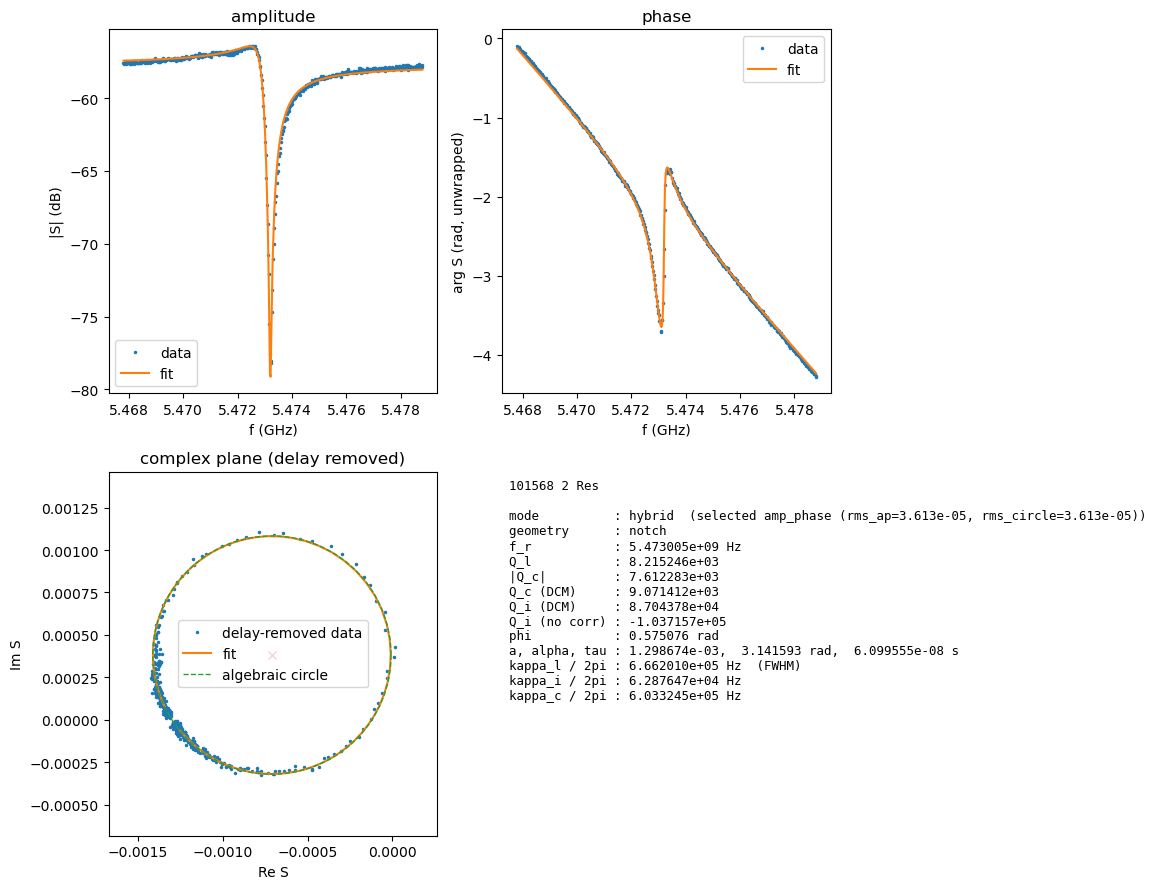

mode          : hybrid  (selected amp_phase (rms_ap=3.613e-05, rms_circle=3.613e-05))
geometry      : notch
f_r           : 5.473005e+09 Hz
Q_l           : 8.215246e+03
|Q_c|         : 7.612283e+03
Q_c (DCM)     : 9.071412e+03
Q_i (DCM)     : 8.704378e+04
Q_i (no corr) : -1.037157e+05
phi           : 0.575076 rad
a, alpha, tau : 1.298674e-03,  3.141593 rad,  6.099555e-08 s
kappa_l / 2pi : 6.662010e+05 Hz  (FWHM)
kappa_i / 2pi : 6.287647e+04 Hz
kappa_c / 2pi : 6.033245e+05 Hz
101570


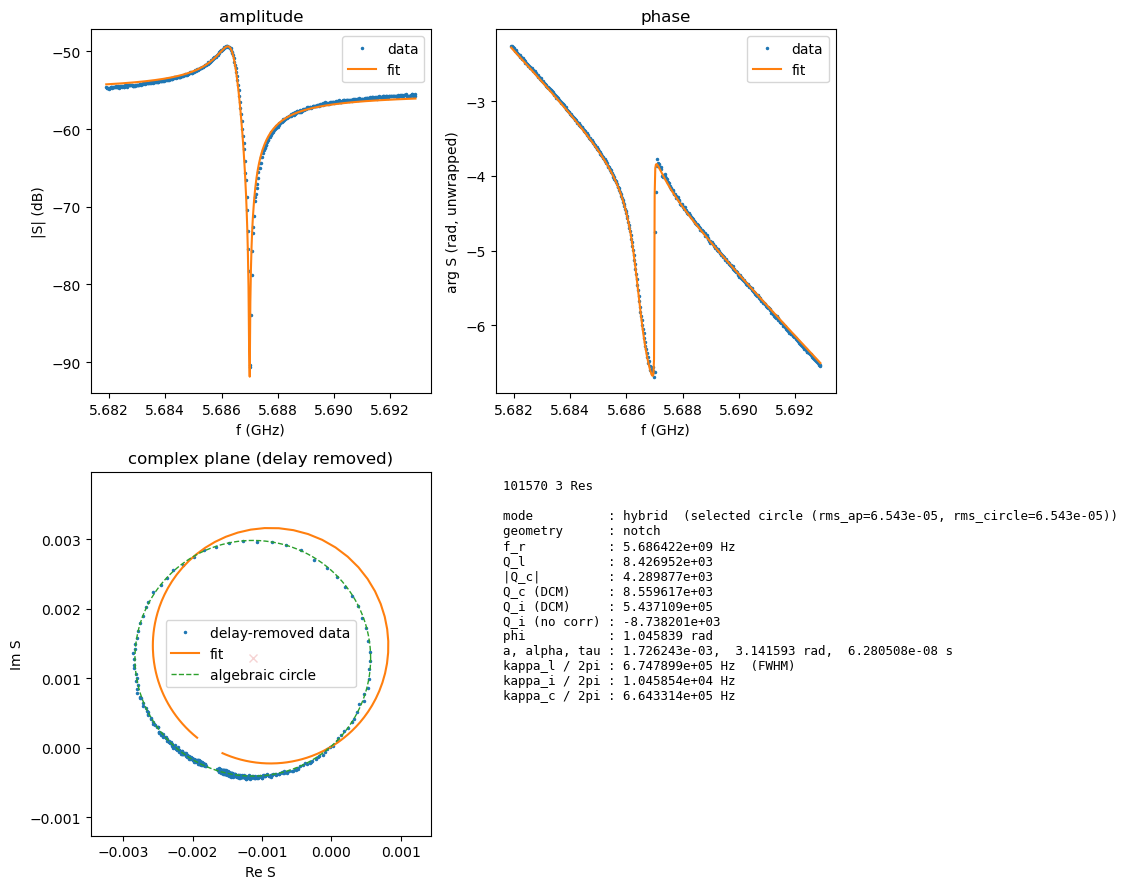

mode          : hybrid  (selected circle (rms_ap=6.543e-05, rms_circle=6.543e-05))
geometry      : notch
f_r           : 5.686422e+09 Hz
Q_l           : 8.426952e+03
|Q_c|         : 4.289877e+03
Q_c (DCM)     : 8.559617e+03
Q_i (DCM)     : 5.437109e+05
Q_i (no corr) : -8.738201e+03
phi           : 1.045839 rad
a, alpha, tau : 1.726243e-03,  3.141593 rad,  6.280508e-08 s
kappa_l / 2pi : 6.747899e+05 Hz  (FWHM)
kappa_i / 2pi : 1.045854e+04 Hz
kappa_c / 2pi : 6.643314e+05 Hz
101572


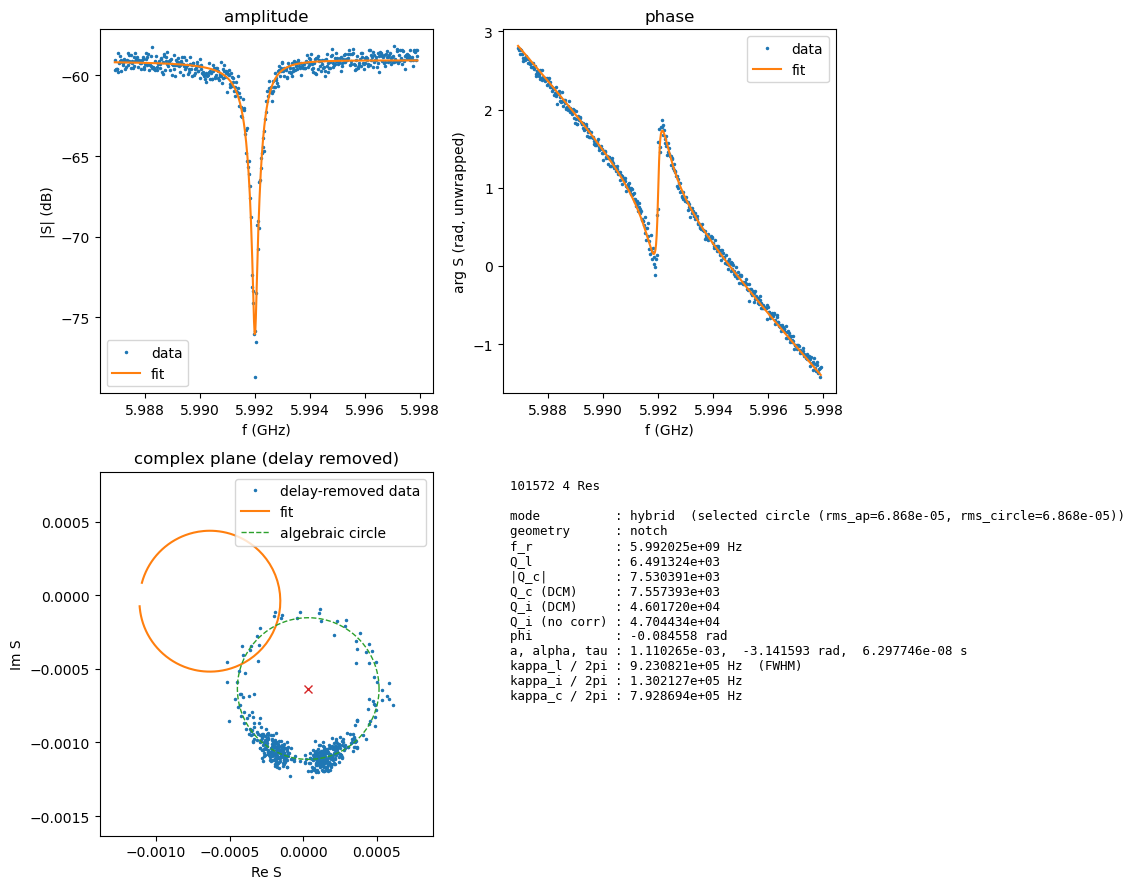

mode          : hybrid  (selected circle (rms_ap=6.868e-05, rms_circle=6.868e-05))
geometry      : notch
f_r           : 5.992025e+09 Hz
Q_l           : 6.491324e+03
|Q_c|         : 7.530391e+03
Q_c (DCM)     : 7.557393e+03
Q_i (DCM)     : 4.601720e+04
Q_i (no corr) : 4.704434e+04
phi           : -0.084558 rad
a, alpha, tau : 1.110265e-03,  -3.141593 rad,  6.297746e-08 s
kappa_l / 2pi : 9.230821e+05 Hz  (FWHM)
kappa_i / 2pi : 1.302127e+05 Hz
kappa_c / 2pi : 7.928694e+05 Hz
101574


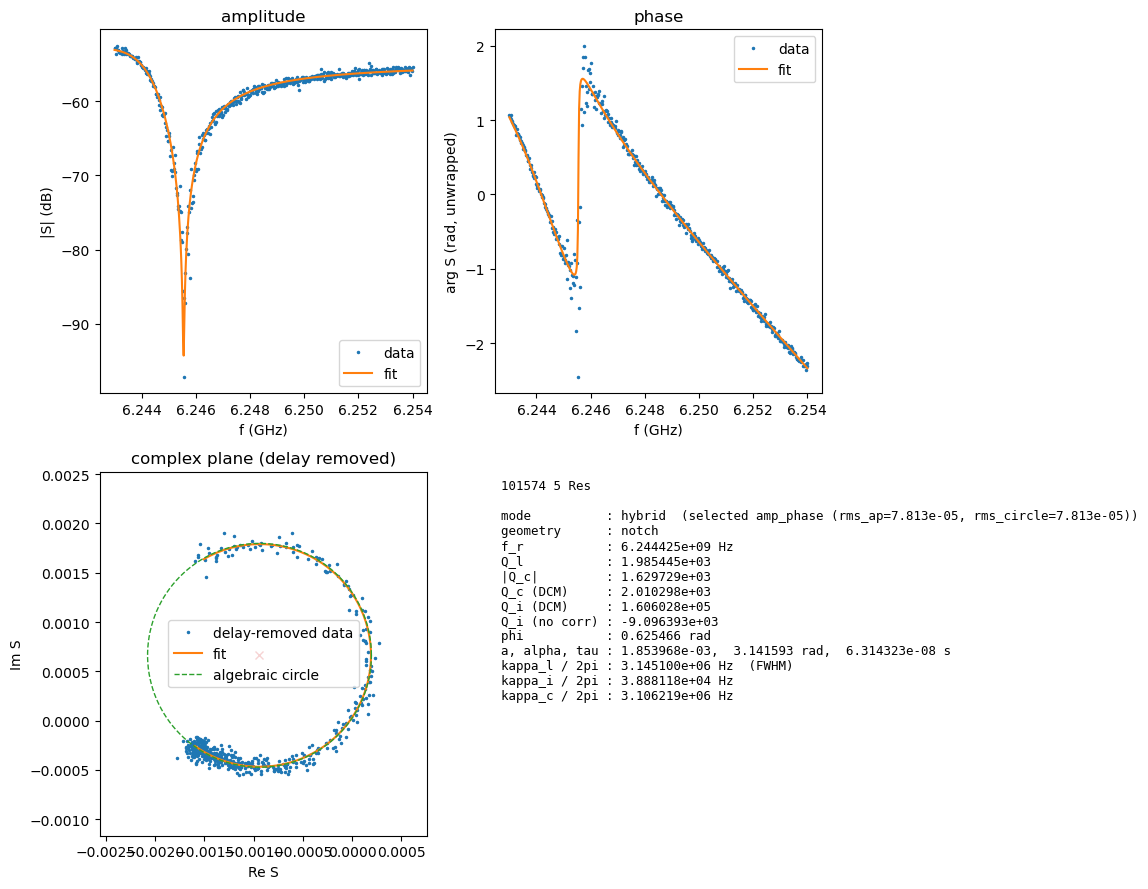

mode          : hybrid  (selected amp_phase (rms_ap=7.813e-05, rms_circle=7.813e-05))
geometry      : notch
f_r           : 6.244425e+09 Hz
Q_l           : 1.985445e+03
|Q_c|         : 1.629729e+03
Q_c (DCM)     : 2.010298e+03
Q_i (DCM)     : 1.606028e+05
Q_i (no corr) : -9.096393e+03
phi           : 0.625466 rad
a, alpha, tau : 1.853968e-03,  3.141593 rad,  6.314323e-08 s
kappa_l / 2pi : 3.145100e+06 Hz  (FWHM)
kappa_i / 2pi : 3.888118e+04 Hz
kappa_c / 2pi : 3.106219e+06 Hz
101576


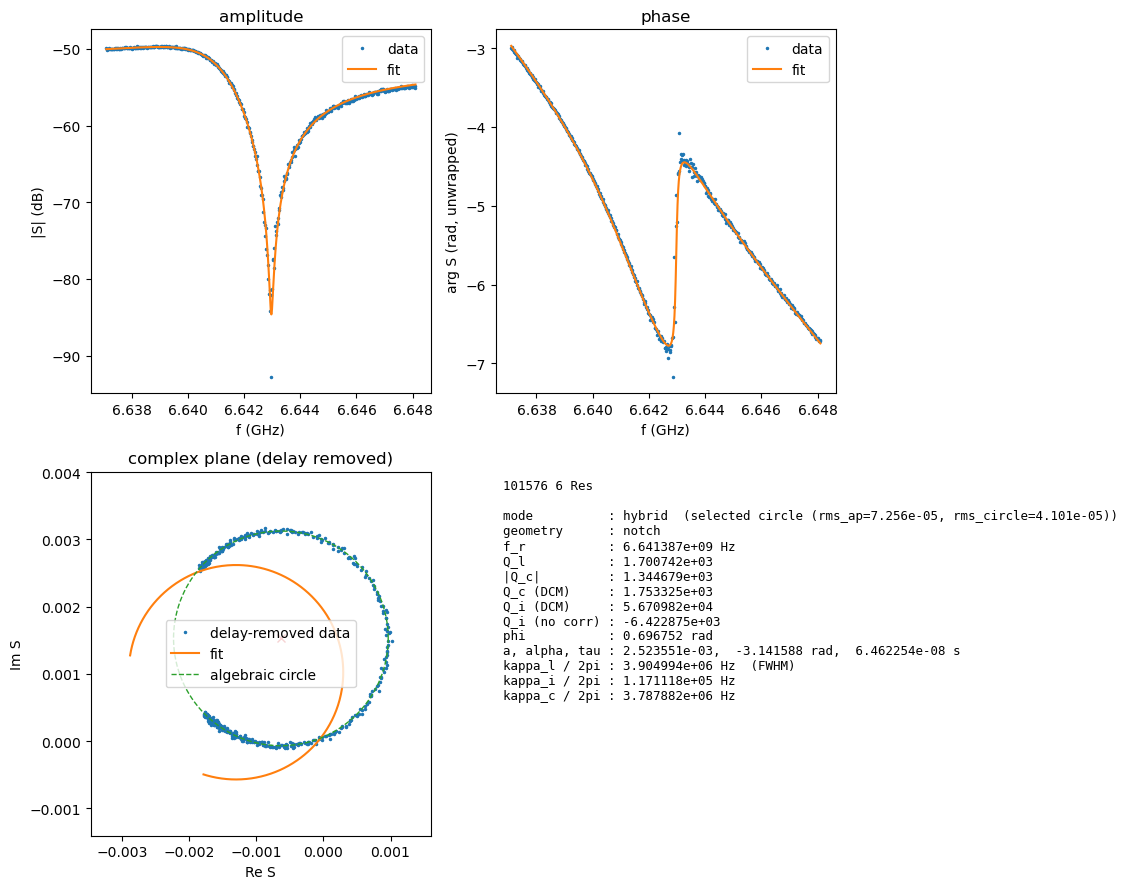

mode          : hybrid  (selected circle (rms_ap=7.256e-05, rms_circle=4.101e-05))
geometry      : notch
f_r           : 6.641387e+09 Hz
Q_l           : 1.700742e+03
|Q_c|         : 1.344679e+03
Q_c (DCM)     : 1.753325e+03
Q_i (DCM)     : 5.670982e+04
Q_i (no corr) : -6.422875e+03
phi           : 0.696752 rad
a, alpha, tau : 2.523551e-03,  -3.141588 rad,  6.462254e-08 s
kappa_l / 2pi : 3.904994e+06 Hz  (FWHM)
kappa_i / 2pi : 1.171118e+05 Hz
kappa_c / 2pi : 3.787882e+06 Hz
101578


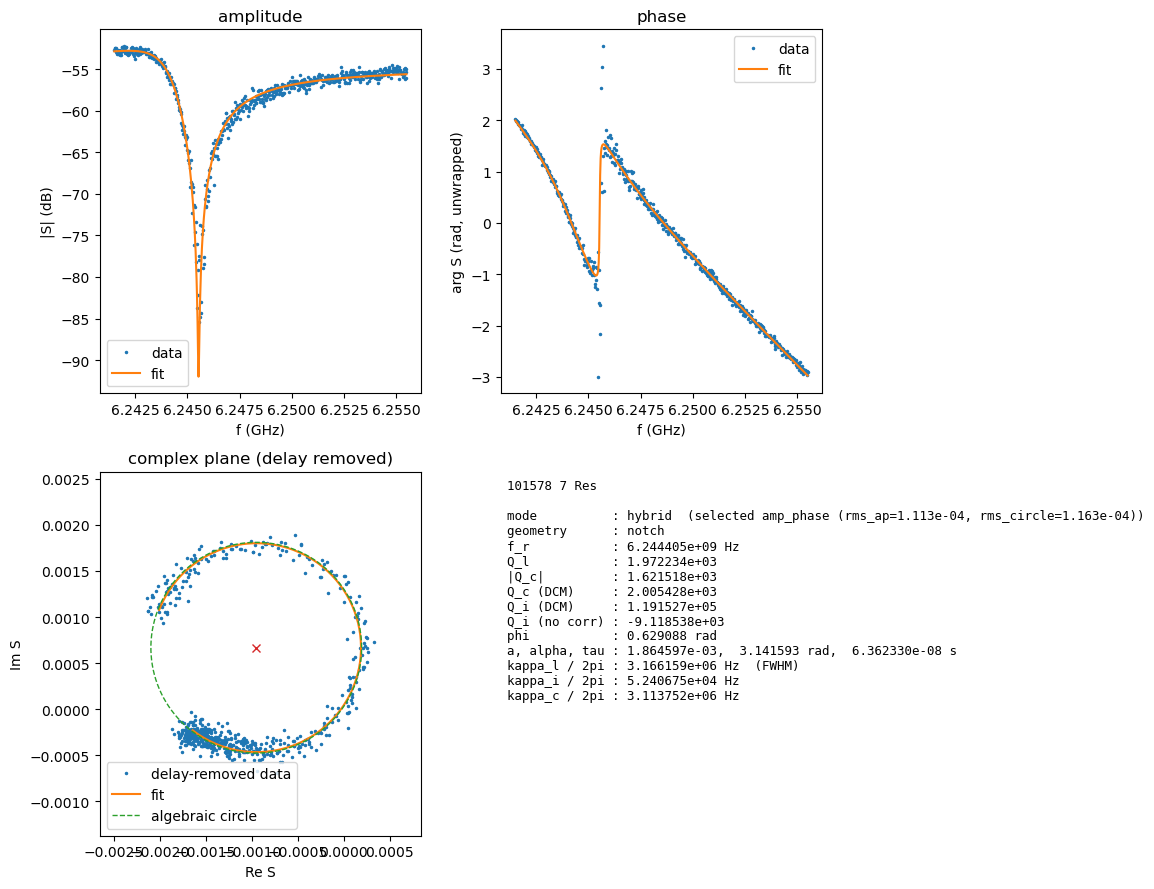

mode          : hybrid  (selected amp_phase (rms_ap=1.113e-04, rms_circle=1.163e-04))
geometry      : notch
f_r           : 6.244405e+09 Hz
Q_l           : 1.972234e+03
|Q_c|         : 1.621518e+03
Q_c (DCM)     : 2.005428e+03
Q_i (DCM)     : 1.191527e+05
Q_i (no corr) : -9.118538e+03
phi           : 0.629088 rad
a, alpha, tau : 1.864597e-03,  3.141593 rad,  6.362330e-08 s
kappa_l / 2pi : 3.166159e+06 Hz  (FWHM)
kappa_i / 2pi : 5.240675e+04 Hz
kappa_c / 2pi : 3.113752e+06 Hz


In [400]:
for i in range(7):
    meas_num = f'{101566 + 2*i}'
    print(meas_num)
    plot_fit_report(Meas_dict[f'{meas_num}']['data_params']['omega_data'], 
                    Meas_dict[f'{meas_num}']['data_params']['S21_data'], 
                    Meas_dict[f'{meas_num}']['data_params']['fit_hybrid'], title = f'{meas_num} {i+1} Res')
    plt.show()
    print(Meas_dict[f'{meas_num}']['data_params']['fit_hybrid'].summary())

In [398]:
print(Meas_dict['101566']['data_params']['fit_hybrid'].summary())

mode          : hybrid  (selected amp_phase (rms_ap=2.103e-05, rms_circle=2.103e-05))
geometry      : notch
f_r           : 5.258796e+09 Hz
Q_l           : 1.236037e+04
|Q_c|         : 1.068864e+04
Q_c (DCM)     : 1.497455e+04
Q_i (DCM)     : 7.080269e+04
Q_i (no corr) : -7.902940e+04
phi           : -0.775905 rad
a, alpha, tau : 1.498453e-03,  -3.141593 rad,  6.205744e-08 s
kappa_l / 2pi : 4.254563e+05 Hz  (FWHM)
kappa_i / 2pi : 7.427396e+04 Hz
kappa_c / 2pi : 3.511823e+05 Hz


# FLIPCHIP SIMUL OLD

In [512]:
names = ['S_21_X-mon_2D_res_tml_5_55', 'S_21_X-mon_3D_res_tml_5_55', 'S21_X-mon_2D_res_gnd_tml', 'S21_X-mon_3D_res_tml_6Q_8mkm', 'S21_X-mon_3D_res_tml_6Q_8mkm_500mhz', 'S21_X-mon_3D_res_tml_6Q_9mkm', 'S21_X-mon_3D_res_tml_6Q_9mkm_500mhz', 'S21_X-mon_3D_res_tml_6Q_10mkm', 'S21_X-mon_3D_res_tml_6Q_10mkm_500mhz', 'S21_X-mon_3D_res_tml_6Q_11mkm', 'S21_X-mon_3D_res_tml_6Q_11mkm_500mhz', 'S21_X-mon_3D_res_tml_6Q_12mkm', 'S21_X-mon_3D_res_tml_6Q_12mkm_500mhz', 'S21_X-mon_3D_res_tml_8mkm', 'S21_X-mon_3D_res_tml_9mkm', 'S21_X-mon_3D_res_tml_11mkm']

S21_X-mon_3D_res_tml_9mkm


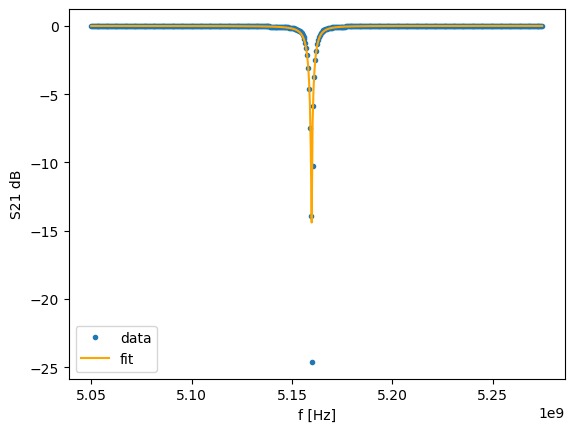

mode          : magnitude  (tau and alpha cannot be recovered from magnitude alone)
geometry      : notch
f_r           : 5.159736e+09 Hz
Q_l           : 9.237011e+02
|Q_c|         : 9.236209e+02
Q_c (DCM)     : 9.237012e+02
Q_i (DCM)     : 1.122124e+10
Q_i (no corr) : -1.063740e+07
phi           : -0.013184 rad
a, alpha, tau : 1.001453e+00,  0.000000 rad,  0.000000e+00 s
kappa_l / 2pi : 5.585936e+06 Hz  (FWHM)
kappa_i / 2pi : 4.598187e-01 Hz
kappa_c / 2pi : 5.585936e+06 Hz


In [710]:
title = 'FlipChip old sim by ansys'

for a in names[14:15]:
    print(a)

    meas_num = f'{a}'
    subject = f'{a}'
    link = fr'C:\Users\Professional\Documents\Romas_lib\NOTES\FlipChip\Files\{a}.csv'
    b, c = 9000, 9500
    df = pd.read_csv(link, delimiter = ',')
    S21_data = (df['dB(S(2,1)) []'].to_numpy())[b:c]
    omega_data = ((df['Freq [GHz]'] * 1e9).to_numpy())[b:c]
    
    Meas_dict[f'{meas_num}'] = copy.deepcopy(typo)
    Meas_dict[f'{meas_num}']['title'] = title
    Meas_dict[f'{meas_num}']['subject'] = subject
    Meas_dict[f'{meas_num}']['data_params']['S21_data'] = S21_data
    Meas_dict[f'{meas_num}']['data_params']['omega_data'] = omega_data
    
    fit_amp_only = fit_magnitude_only(omega_data, 10**(S21_data/10), geometry="notch")
    Meas_dict[f'{meas_num}']['data_params']['fit_amp'] = fit_amp_only

    plt.plot(Meas_dict[f'{meas_num}']['data_params']['omega_data'], 
             Meas_dict[f'{meas_num}']['data_params']['S21_data'], 
             '.', label = "data")
    
    plt.plot(Meas_dict[f'{meas_num}']['data_params']['omega_data'], 
             10*np.log10(np.abs(model_s(omega_data, Meas_dict[f'{meas_num}']['data_params']['fit_amp'].params))), 
             '-', label = "fit", color = 'orange')
    
    plt.legend()
    plt.xlabel('f [Hz]') 
    plt.ylabel('S21 dB')
    plt.show()
    print(Meas_dict[f'{meas_num}']['data_params']['fit_amp'].summary())



In [398]:
print(Meas_dict['101566']['data_params']['fit_hybrid'].summary())

mode          : hybrid  (selected amp_phase (rms_ap=2.103e-05, rms_circle=2.103e-05))
geometry      : notch
f_r           : 5.258796e+09 Hz
Q_l           : 1.236037e+04
|Q_c|         : 1.068864e+04
Q_c (DCM)     : 1.497455e+04
Q_i (DCM)     : 7.080269e+04
Q_i (no corr) : -7.902940e+04
phi           : -0.775905 rad
a, alpha, tau : 1.498453e-03,  -3.141593 rad,  6.205744e-08 s
kappa_l / 2pi : 4.254563e+05 Hz  (FWHM)
kappa_i / 2pi : 7.427396e+04 Hz
kappa_c / 2pi : 3.511823e+05 Hz


# Grisha Mesura

In [110]:
# link1 = "Z:\\data\\2026-08-24\\"
link1 = "C:\\Users\\Professional\\Desktop\\Буффер\\"
link2_data = "\\delay\\data\\data.npy"
link2_y = "\\delay\\parameters\\1\\data.npy"
link2_x = "\\delay\\parameters\\0\\data.npy"

meas_num = '053672'

data1 = np.load(link1 + f"{meas_num}.exdir" + link2_data)

try:
    y1 = np.load(link1 + f"{meas_num}.exdir" + link2_y)       #power
    x1 = np.load(link1 + f"{meas_num}.exdir" + link2_x)       #freq
    subject+=' 3D data'
    print("3D data")
except FileNotFoundError:
    y1 = [1]
    x1 = np.load(link1 + f"{meas_num}.exdir" + link2_x)       #freq
    subject+=' 2D data'
    print("2D data")
    
# # Нормализую назване
power_data = copy.deepcopy(x1)
omega_data = copy.deepcopy(y1)
delay_data = copy.deepcopy(data1)


3D data


In [118]:
print(power_data)

[-10. -15. -20. -25. -30. -35. -40. -45. -50. -55. -60.]


In [114]:
print(omega_data)

[6.8480e+09 6.8481e+09 6.8482e+09 6.8483e+09 6.8484e+09 6.8485e+09
 6.8486e+09 6.8487e+09 6.8488e+09 6.8489e+09 6.8490e+09 6.8491e+09
 6.8492e+09 6.8493e+09 6.8494e+09 6.8495e+09 6.8496e+09 6.8497e+09
 6.8498e+09 6.8499e+09 6.8500e+09 6.8501e+09 6.8502e+09 6.8503e+09
 6.8504e+09 6.8505e+09 6.8506e+09 6.8507e+09 6.8508e+09 6.8509e+09
 6.8510e+09 6.8511e+09 6.8512e+09 6.8513e+09 6.8514e+09 6.8515e+09
 6.8516e+09 6.8517e+09 6.8518e+09 6.8519e+09 6.8520e+09 6.8521e+09
 6.8522e+09 6.8523e+09 6.8524e+09 6.8525e+09 6.8526e+09 6.8527e+09
 6.8528e+09 6.8529e+09 6.8530e+09 6.8531e+09 6.8532e+09 6.8533e+09
 6.8534e+09 6.8535e+09 6.8536e+09 6.8537e+09 6.8538e+09 6.8539e+09
 6.8540e+09 6.8541e+09 6.8542e+09 6.8543e+09 6.8544e+09 6.8545e+09
 6.8546e+09 6.8547e+09 6.8548e+09 6.8549e+09 6.8550e+09 6.8551e+09
 6.8552e+09 6.8553e+09 6.8554e+09 6.8555e+09 6.8556e+09 6.8557e+09
 6.8558e+09 6.8559e+09 6.8560e+09 6.8561e+09 6.8562e+09 6.8563e+09
 6.8564e+09 6.8565e+09 6.8566e+09 6.8567e+09 6.8568e+09 6.8569

In [122]:
print(delay_data[:2])

[[9.11638622e-08 9.12187872e-08 9.11481166e-08 9.12314704e-08
  9.12332325e-08 9.13648890e-08 9.13749787e-08 9.13974176e-08
  9.14823275e-08 9.16158669e-08 9.17036544e-08 9.18160694e-08
  9.18758545e-08 9.20521970e-08 9.22480794e-08 9.22810983e-08
  9.23547461e-08 9.24141119e-08 9.25787234e-08 9.26451591e-08
  9.26527406e-08 9.27043544e-08 9.27946502e-08 9.28989081e-08
  9.28510104e-08 9.28863386e-08 9.30760891e-08 9.32990574e-08
  9.33543944e-08 9.34800113e-08 9.37128846e-08 9.38883105e-08
  9.43488061e-08 9.42518454e-08 9.45814094e-08 9.47844043e-08
  9.49144265e-08 9.52937356e-08 9.56213313e-08 9.58197859e-08
  9.60557216e-08 9.63370326e-08 9.64136149e-08 9.70309770e-08
  9.72429177e-08 9.76516858e-08 9.80631114e-08 9.81925226e-08
  9.85568960e-08 9.89371145e-08 9.94206530e-08 9.98138034e-08
  1.00253992e-07 1.00598065e-07 1.01136052e-07 1.01681216e-07
  1.02225357e-07 1.02863083e-07 1.03449629e-07 1.04234928e-07
  1.04869166e-07 1.05678168e-07 1.06514904e-07 1.07463315e-07
  1.0834

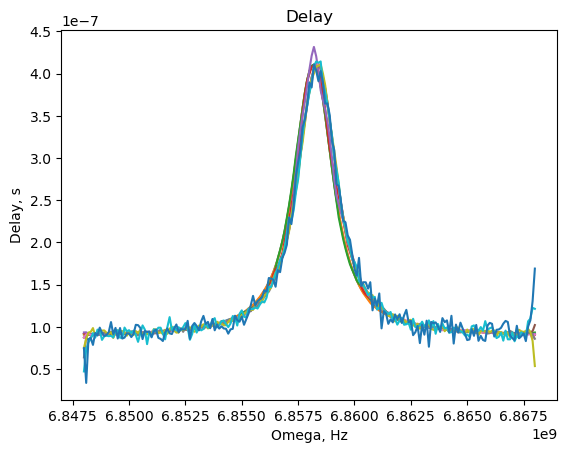

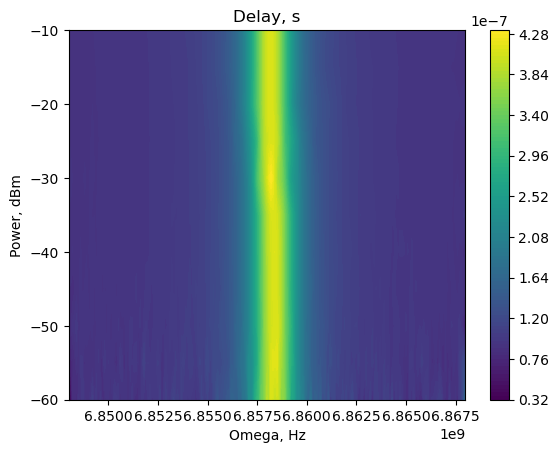

In [112]:
for i in range(len(delay_data[:, 0])):
    plt.plot(omega_data, delay_data[i, :])
plt.title('Delay')
plt.xlabel('Omega, Hz')
plt.ylabel('Delay, s')
plt.show()
plt.contourf(omega_data, power_data, delay_data, levels = 100)
plt.colorbar()
plt.title('Delay, s')
plt.xlabel('Omega, Hz')
plt.ylabel('Power, dBm')
plt.show()

# Delay и S-параметр: две разные задержки

В эксперименте слово **delay** означает почти всегда **групповую задержку** $\tau_g(f)$ (формат Delay на VNA, канал `delay` в qsweepy/exdir). В модели Probst символ $\tau$ — это **электрическая (кабельная) задержка**, константа тракта. Их нельзя подставлять друг в друга как одно число.

## Определения

Комплексный $S_{21}=|S|e^{i\phi(f)}$.

$$
\tau_g(f)=-\frac{d\phi}{d\omega}=-\frac{1}{2\pi}\frac{d\phi}{df}
\qquad (\phi\ \text{в радианах},\ f\ \text{в герцах}).
$$

Эквивалентная устойчивая формула без unwrap:

$$
\tau_g=-\frac{1}{2\pi}\,\mathrm{Im}\left(\frac{1}{S}\frac{dS}{df}\right).
$$

Кабель даёт $\phi_{\mathrm{cab}}=\alpha-2\pi f\tau_{\mathrm{el}}$, поэтому

$$
\tau_g(f)=\tau_{\mathrm{el}}+\tau_{g,\mathrm{res}}(f).
$$

Базовая полка на вашем 2D-графике (~50–100 ns) — это $\tau_{\mathrm{el}}$ (кабель + усилители). Светлая вертикальная полоса (~400 ns при 6.858 GHz) — резонатор: энергия «живёт» в моде время $\sim Q_l/\omega$, и групповая задержка в пике для through-Lorentzian равна

$$
\tau_g^{\mathrm{peak}}-\tau_{\mathrm{el}}=\frac{Q_l}{\pi f_r}=2\,t_{\mathrm{ph}},\qquad t_{\mathrm{ph}}=\frac{Q_l}{2\pi f_r}.
$$

Оценка с картинки: экстра $\approx 300$ ns при $f_r\approx 6.858$ GHz $\Rightarrow$ $Q_l\approx \pi f_r\cdot 300\,\mathrm{ns}\approx 6.5\times 10^3$. Ширина полосы $\Delta f\approx f_r/Q_l\sim 1$ MHz.

## Что получается из чего

| Есть | Можно получить |
|---|---|
| комплексный $S$ | $\tau_g(f)$ однозначно; $\tau_{\mathrm{el}}$ фитом круга/фазы |
| только $\tau_g(f)$ | фаза $\phi(f)=\alpha-2\pi\int\tau_g\,df$; $f_r$, $Q_l$, $\tau_{\mathrm{el}}$; для notch ещё $|Q_c|,\varphi,Q_i$ |
| только $\tau_g$ | **нельзя** восстановить $|S|$ и круг на комплексной плоскости |
| scalar Electrical Delay на VNA | это как раз $\tau_{\mathrm{el}}$, не резонансный пик |

Знак: IEEE/VNA для hanger $S_{21}$ даёт **провал** $\tau_g$ (аномальная дисперсия у поглощения). qsweepy часто рисует **пик** (как на скрине 53672) — это $-\tau_g^{\mathrm{IEEE}}$ либо through-геометрия. `fit_group_delay(..., geometry="notch")` сам ставит `sign=-1`, если в данных пик.

Through-линия: высота пика задержки **не зависит** от связи, $Q_i$ из delay не извлечь. Notch: высота кодирует $d=Q_l/|Q_c|$.



## Мощность

Каждый горизонтальный срез карты — свой $\tau_g(f)$ при фиксированной мощности. TLS: на малой мощности $Q_i$ меньше (пик ниже и шире), на большой — $Q_i$ растёт. Керр: $f_r$ ползёт с мощностью. Поэтому фитить нужно **посрезово**, затем строить $f_r(P)$, $Q_l(P)$, $Q_i(P)$.

На скрине около $-25$ dBm в центре полосы есть «провал» — это не баг delay, а скорее связанная мода / кубит / TLS. Однорезонаторная модель там будет врать; вырезайте окрестность или фитьте две моды.



## Оси в ячейке Grisha Mesura

В загрузке `x1` помечен как freq (`parameters/0`), `y1` как power (`parameters/1`), но затем

```
power_data = copy.deepcopy(x1)
omega_data = copy.deepcopy(y1)
```

то есть оси **переставлены** относительно комментариев. Если `contourf` не совпадает со скрином qsweepy, используйте `orient_delay_sweep` — он смотрит, у какой оси значения ~ГГц.



In [ ]:
from sparam_fit import fit_group_delay, fit_group_delay_vs_power, group_delay_from_s
from sparam_fit.group_delay import group_delay_model, orient_delay_sweep, phase_from_group_delay
from sparam_fit.plots import plot_group_delay_fit, plot_delay_power_map

# Если комплексный S уже есть — delay из него:
# tau_g = group_delay_from_s(omega_data_s, S21_data_s)

# Карта delay из exdir (подставьте свои x1, y1, data1 из ячейки Grisha):
# freq_hz, power_dBm, delay_s = orient_delay_sweep(x1, y1, data1)
# plot_delay_power_map(freq_hz, power_dBm, delay_s)
# r = fit_group_delay(freq_hz, delay_s[0], geometry='notch')  # один срез
# print(r.summary())
# plot_group_delay_fit(freq_hz, delay_s[0], r)
# fits, vs_p = fit_group_delay_vs_power(freq_hz, power_dBm, delay_s, geometry='notch')
# plt.plot(vs_p['power'], vs_p['Ql']); plt.xlabel('dBm'); plt.ylabel('Q_l')

# Демо на синтетике в той же полосе, что скрин 53672:
from sparam_fit.models import ResonatorParams
from sparam_fit.synthetic import make_trace
true = ResonatorParams(fr=6.858e9, Ql=6500, absQc=11000, phi=0.08, a=0.02, tau=70e-9, geometry='notch')
f_demo, s_demo = make_trace(true, n=601, span_bw=12.0, snr=80, seed=1)
tg_ieee = group_delay_from_s(f_demo, s_demo)
tg_like_qsweepy = -tg_ieee  # пик, как на скриншоте
r_delay = fit_group_delay(f_demo, tg_like_qsweepy, geometry='notch')
print(r_delay.summary())
print('sign (auto) =', r_delay.diagnostics['sign'], '  (ожидаем -1 для hanger-пика)')
plot_group_delay_fit(f_demo, tg_like_qsweepy, r_delay, title='synthetic delay like 53672')
plt.show()


## Практический рецепт для 53672

1. `freq, power, delay = orient_delay_sweep(x1, y1, data1)` — delay в **секундах**.
2. Выберите срез далеко от аномалии (~$-50$ dBm или ~$-10$ dBm).
3. `fit_group_delay(freq, delay[i], geometry="notch")` если это hanger readout. Если пик не фитится, попробуйте `geometry="transmission"` (тогда $Q_i$ не доверять).
4. Проверка: $Q_l \approx \pi f_r (\tau_{\mathrm{peak}}-\tau_{\mathrm{полка}})$ по порядку величины.
5. Весь 2D прогон: `fit_group_delay_vs_power`.
6. Если позже появится полный $S_{21}$ на той же трассе — `fit_hybrid` должен дать тот же $f_r,Q_l$; $\tau$ кругового фита = полка групповой задержки.

Кабель из $S$: $S\leftarrow S\,e^{+2\pi i f\tau_{\mathrm{el}}}$. Кабель из delay: вычесть полку $\tau_g-\langle\tau_g\rangle_{\mathrm{края}}$. Это одно и то же $\tau_{\mathrm{el}}$.

